# Analise exploratoria


In [127]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [128]:
conn = sqlite3.connect('/workspaces/moneyball-brasileirao/databases/brasileirao.db')

In [129]:
anos = range(2015, 2026)
dfs = []

for ano in anos:
    query = f"""
    SELECT 
        d.clube, d.numero_jogadores, d.media_idade, d.estrangeiros,
        d.media_valor_mercado_, d.valor_mercado_total,  
        ROW_NUMBER() OVER (ORDER BY c.pontos DESC) AS posicao_final,
        c.v, c.e, c.d, c.gols_pro, c.gols_contra, c.sg, c.pontos,
        {ano} AS temporada 
    FROM dados_clubes_{ano} AS d
    JOIN dados_class_{ano} AS c 
    ON d.clube = c.clube 
    """
    
    try:
        df_ano = pd.read_sql(query, conn)
        dfs.append(df_ano)
        print(f"Dados de {ano} carregados com sucesso.")
    except Exception as e:
        print(f"Tabela de {ano} não encontrada ou erro: {e}")

df = pd.concat(dfs, ignore_index=True)

print(df)


Tabela de 2015 não encontrada ou erro: Execution failed on sql '
    SELECT 
        d.clube, d.numero_jogadores, d.media_idade, d.estrangeiros,
        d.media_valor_mercado_, d.valor_mercado_total,  
        ROW_NUMBER() OVER (ORDER BY c.pontos DESC) AS posicao_final,
        c.v, c.e, c.d, c.gols_pro, c.gols_contra, c.sg, c.pontos,
        2015 AS temporada 
    FROM dados_clubes_2015 AS d
    JOIN dados_class_2015 AS c 
    ON d.clube = c.clube 
    ': no such table: dados_clubes_2015
Dados de 2016 carregados com sucesso.
Dados de 2017 carregados com sucesso.
Dados de 2018 carregados com sucesso.
Dados de 2019 carregados com sucesso.
Dados de 2020 carregados com sucesso.
Dados de 2021 carregados com sucesso.
Dados de 2022 carregados com sucesso.
Dados de 2023 carregados com sucesso.
Dados de 2024 carregados com sucesso.
Dados de 2025 carregados com sucesso.
             clube  numero_jogadores  media_idade  estrangeiros  \
0        palmeiras              47.0         25.0          

# ETAPA 1 — Inspeção inicial e qualidade dos dados

## 1.1 Tipos, nulos, etc.

In [130]:
display(df.info(), df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   clube                 200 non-null    str    
 1   numero_jogadores      200 non-null    float64
 2   media_idade           200 non-null    float64
 3   estrangeiros          200 non-null    float64
 4   media_valor_mercado_  200 non-null    float64
 5   valor_mercado_total   200 non-null    float64
 6   posicao_final         200 non-null    int64  
 7   v                     200 non-null    int64  
 8   e                     200 non-null    int64  
 9   d                     200 non-null    int64  
 10  gols_pro              200 non-null    int64  
 11  gols_contra           200 non-null    int64  
 12  sg                    200 non-null    int64  
 13  pontos                200 non-null    int64  
 14  temporada             200 non-null    int64  
dtypes: float64(5), int64(9), str(1)
me

None

clube                   0
numero_jogadores        0
media_idade             0
estrangeiros            0
media_valor_mercado_    0
valor_mercado_total     0
posicao_final           0
v                       0
e                       0
d                       0
gols_pro                0
gols_contra             0
sg                      0
pontos                  0
temporada               0
dtype: int64

## 1.2 Distribuição e outliers por variavel

In [131]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num = df_num.drop(columns=['temporada'], errors='ignore')

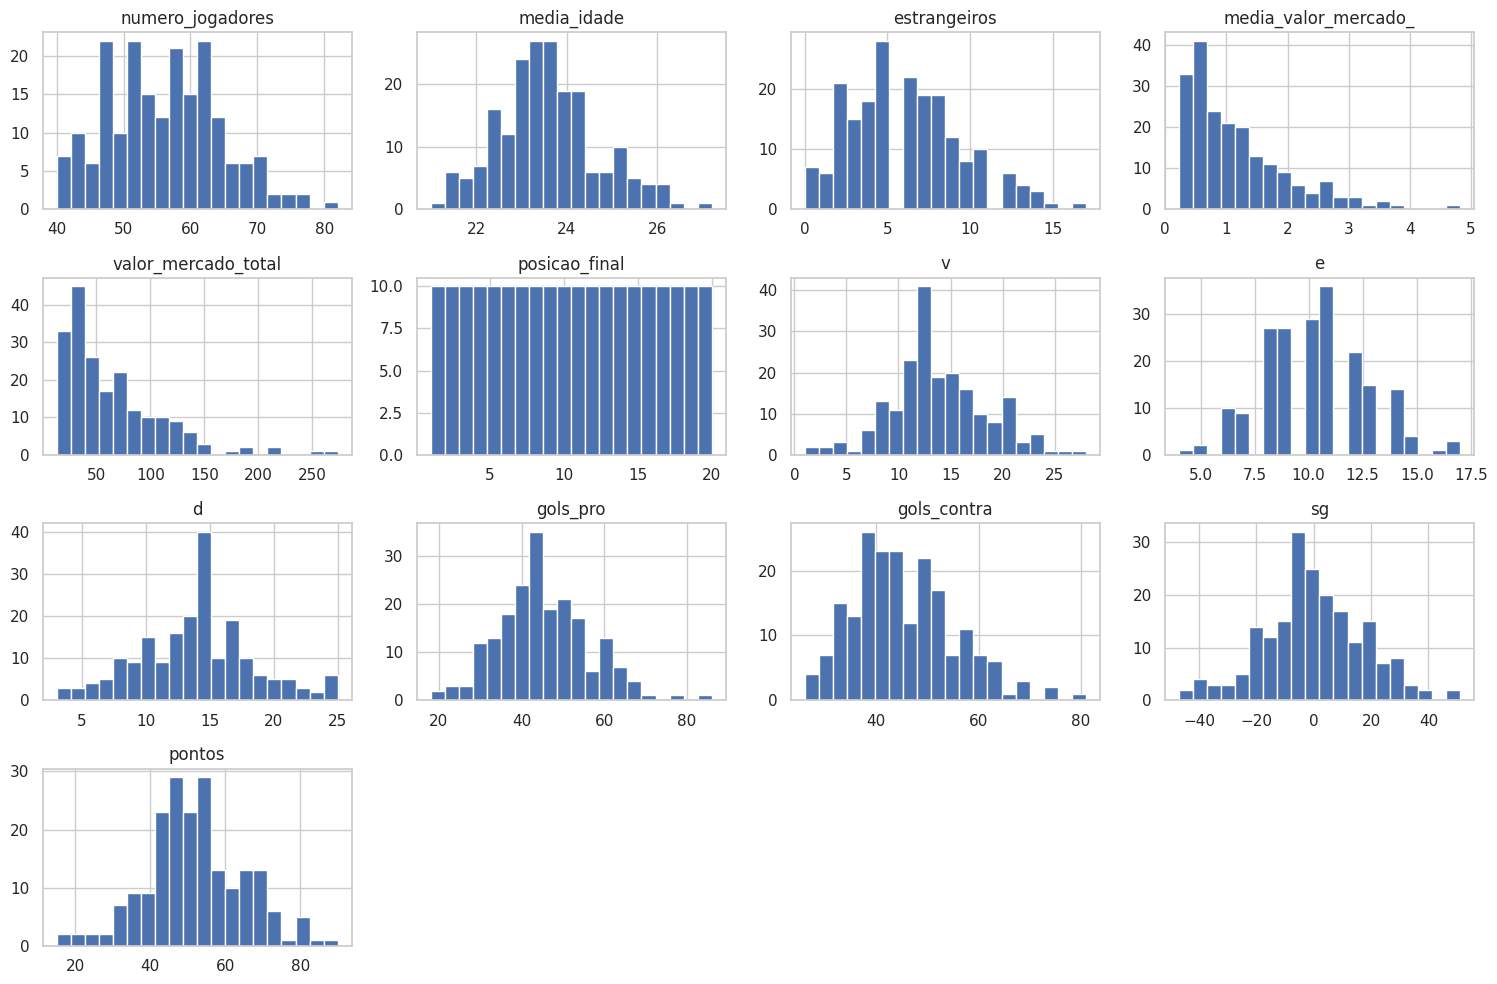

In [132]:
df_num.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

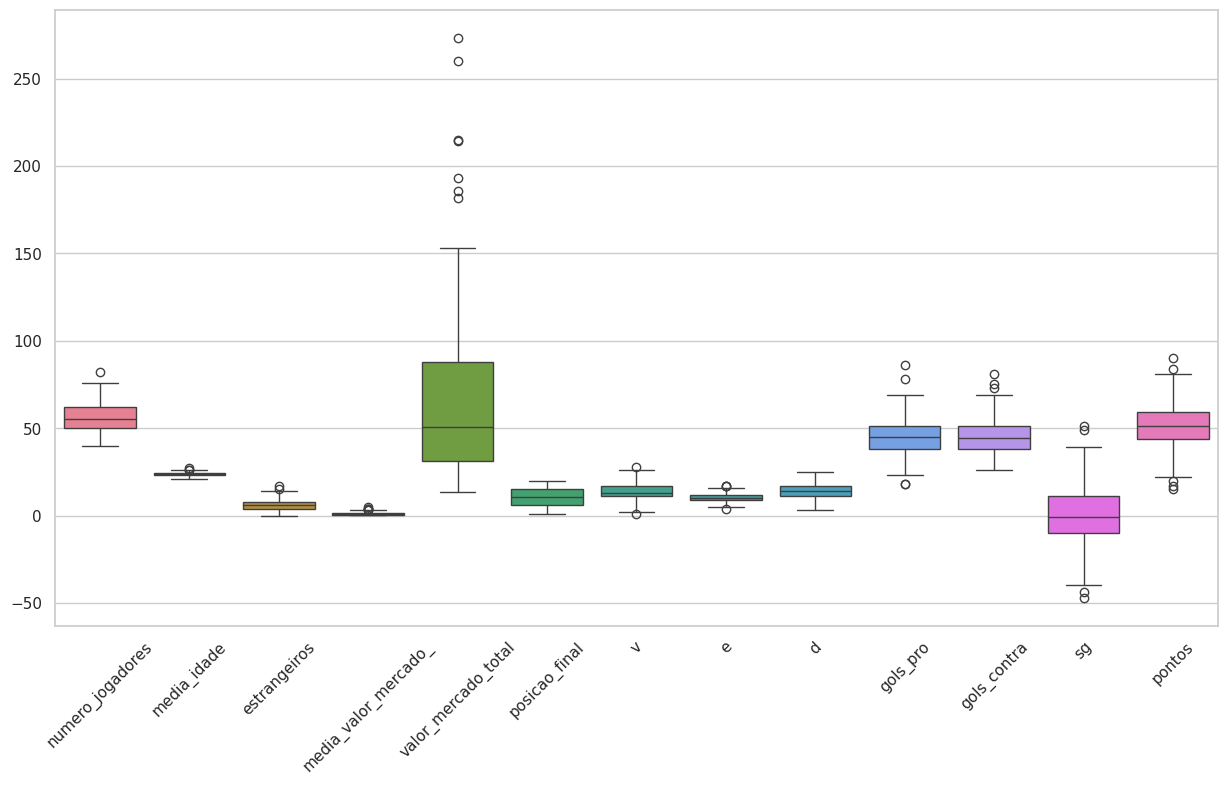

In [133]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_num)
plt.xticks(rotation=45)
plt.show()

In [134]:
def detectar_outliers(df):
    outliers_dict = {}

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

        outliers_dict[col] = len(outliers)

    return pd.DataFrame.from_dict(outliers_dict, orient='index', columns=['qtd_outliers'])

# usar
outliers_df = detectar_outliers(df_num)
print(outliers_df.sort_values(by='qtd_outliers', ascending=False))

                      qtd_outliers
valor_mercado_total              7
media_valor_mercado_             6
pontos                           5
e                                4
gols_pro                         4
sg                               4
gols_contra                      3
media_idade                      3
estrangeiros                     2
v                                2
numero_jogadores                 1
d                                0
posicao_final                    0


In [135]:
df_num.skew().sort_values(ascending=False)

valor_mercado_total     1.681241
media_valor_mercado_    1.374647
gols_contra             0.619041
estrangeiros            0.460469
media_idade             0.444388
gols_pro                0.368042
numero_jogadores        0.351683
v                       0.180097
e                       0.169870
d                       0.141529
pontos                  0.068320
sg                      0.024549
posicao_final           0.000000
dtype: float64

In [136]:
df['log_valor_mercado_total'] = np.log1p(df['valor_mercado_total'])

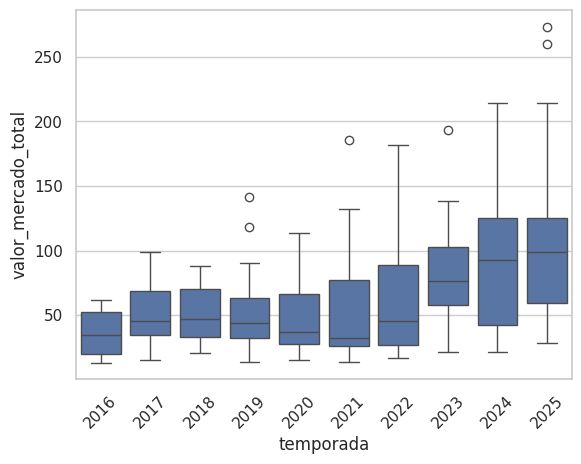

In [137]:
sns.boxplot(x='temporada', y='valor_mercado_total', data=df)
plt.xticks(rotation=45)
plt.show()

## 1.3 Cobertura Temporal

In [138]:
pivot = df.pivot_table(
    index='clube',
    columns='temporada',
    values='pontos',
    aggfunc='count'
)
cobertura = pivot.notnull().astype(int)
display(cobertura)

temporada,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
clube,,,,,,,,,,
americamg,1,0,1,0,0,1,1,1,0,0
athleticopr,0,0,0,1,1,1,1,1,1,0
atleticogo,0,1,0,0,1,1,1,0,1,0
atleticomg,1,1,1,1,1,1,1,1,1,1
atleticopr,1,1,1,0,0,0,0,0,0,0
avai,0,1,0,1,0,0,1,0,0,0
bahia,0,1,1,1,1,1,0,1,1,1
botafogo,1,1,1,1,1,0,1,1,1,1
bragantino,0,0,0,0,1,1,1,1,1,1


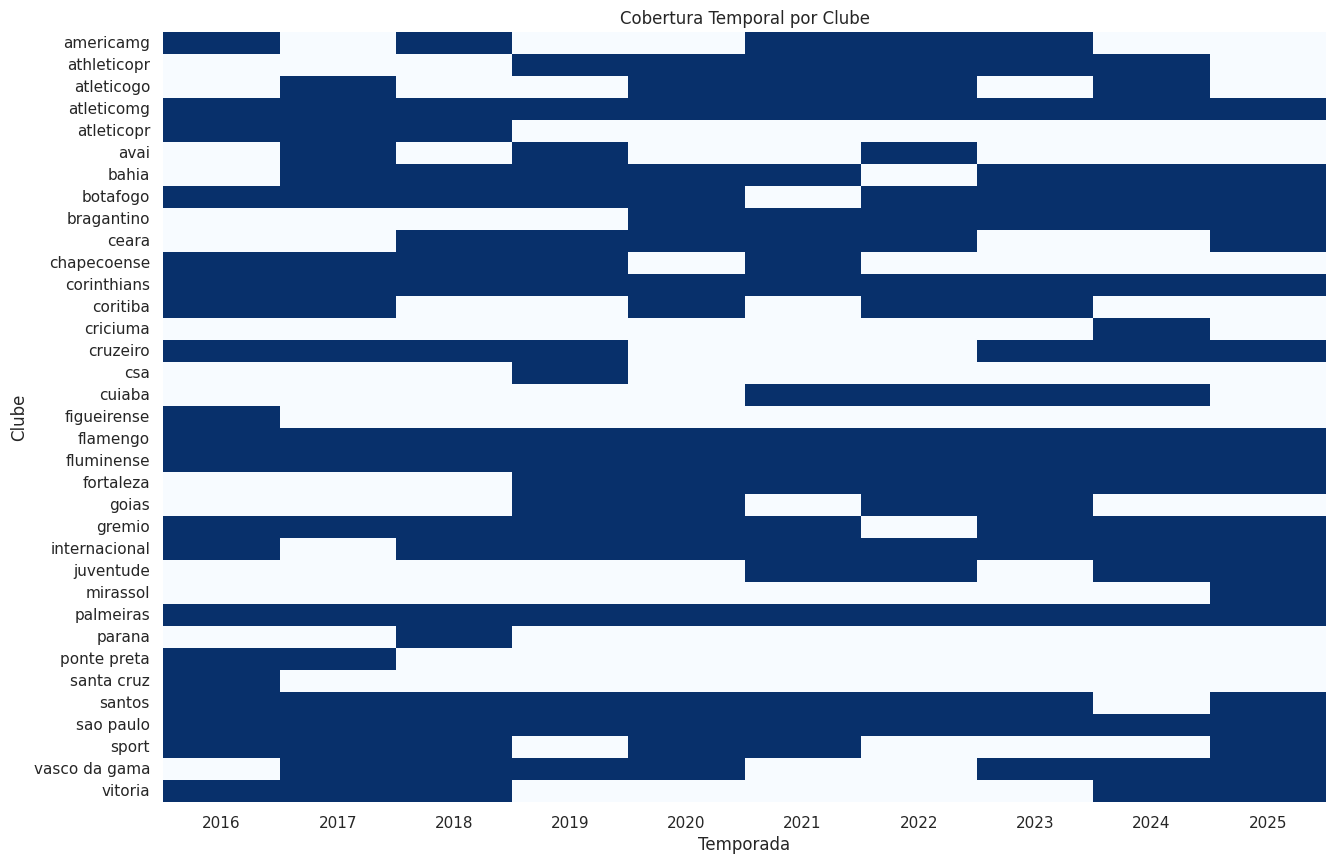

In [139]:
plt.figure(figsize=(15,10))
sns.heatmap(cobertura, cmap='Blues', cbar=False)

plt.title('Cobertura Temporal por Clube')
plt.xlabel('Temporada')
plt.ylabel('Clube')
plt.show()

In [140]:
temporadas_por_clube = df.groupby('clube')['temporada'].nunique().sort_values(ascending=False)

display(temporadas_por_clube)

clube
flamengo         10
corinthians      10
atleticomg       10
palmeiras        10
sao paulo        10
fluminense       10
internacional     9
gremio            9
santos            9
botafogo          9
bahia             8
vasco da gama     7
cruzeiro          7
fortaleza         7
athleticopr       6
sport             6
bragantino        6
ceara             6
americamg         5
atleticogo        5
vitoria           5
coritiba          5
chapecoense       5
goias             4
cuiaba            4
juventude         4
avai              3
atleticopr        3
ponte preta       2
criciuma          1
csa               1
figueirense       1
mirassol          1
santa cruz        1
parana            1
Name: temporada, dtype: int64

In [141]:
def detectar_gaps(df):
    gaps = {}

    for clube, group in df.groupby('clube'):
        anos = sorted(group['temporada'].unique())
        faltantes = []

        for i in range(len(anos)-1):
            if anos[i+1] - anos[i] > 1:
                faltantes.extend(range(anos[i]+1, anos[i+1]))

        if faltantes:
            gaps[clube] = faltantes

    return gaps

gaps = detectar_gaps(df)
display(gaps)

{'americamg': [2017, 2019, 2020],
 'atleticogo': [2018, 2019, 2023],
 'avai': [2018, 2020, 2021],
 'bahia': [2022],
 'botafogo': [2021],
 'ceara': [2023, 2024],
 'chapecoense': [2020],
 'coritiba': [2018, 2019, 2021],
 'cruzeiro': [2020, 2021, 2022],
 'goias': [2021],
 'gremio': [2022],
 'internacional': [2017],
 'juventude': [2023],
 'santos': [2024],
 'sport': [2019, 2022, 2023, 2024],
 'vasco da gama': [2021, 2022],
 'vitoria': [2019, 2020, 2021, 2022, 2023]}

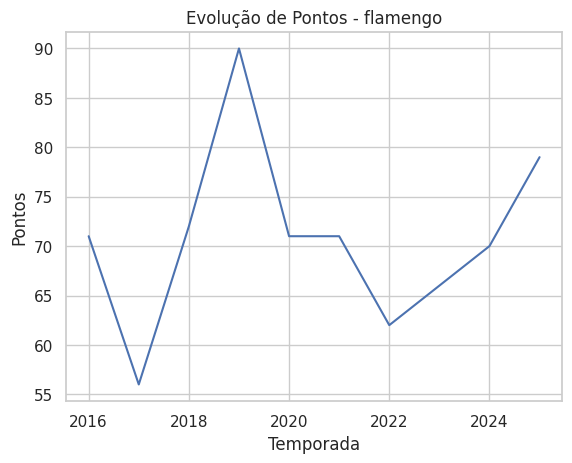

In [142]:
clube_exemplo = 'flamengo'

df_clube = df[df['clube'] == clube_exemplo]

plt.plot(df_clube['temporada'], df_clube['pontos'])
plt.title(f'Evolução de Pontos - {clube_exemplo}')
plt.xlabel('Temporada')
plt.ylabel('Pontos')
plt.show()

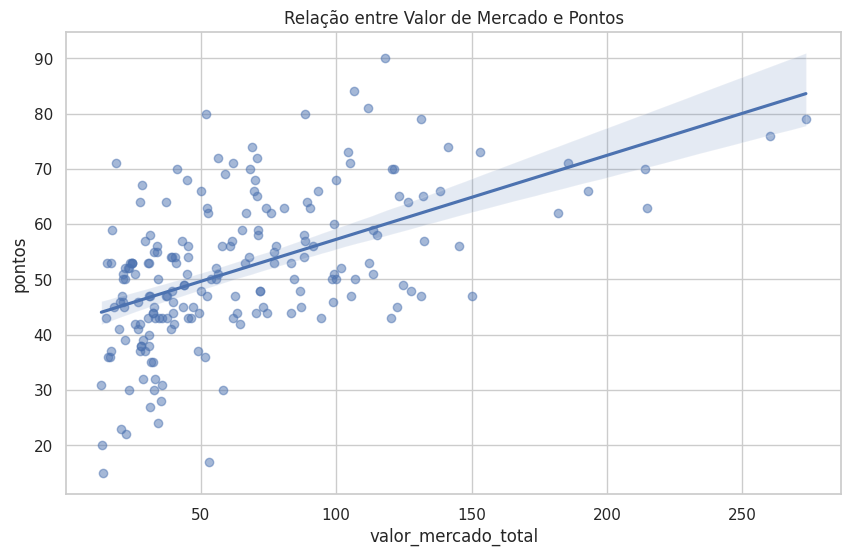

In [143]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='valor_mercado_total',
    y='pontos',
    scatter_kws={'alpha':0.5}
)

plt.title('Relação entre Valor de Mercado e Pontos')
plt.show()

In [144]:
anos_validos = sorted(df[df['temporada'] >= 2015]['temporada'].unique())
total_anos = len(anos_validos)

In [145]:
clubes_completos = (
    df[df['temporada'] >= 2015]
    .groupby('clube')['temporada']
    .nunique()
)

clubes_completos = clubes_completos[clubes_completos == total_anos].index.tolist()

print(clubes_completos)

['atleticomg', 'corinthians', 'flamengo', 'fluminense', 'palmeiras', 'sao paulo']


In [146]:
df_filtrado = df[
    (df['clube'].isin(clubes_completos)) &
    (df['temporada'] >= 2015)
]

In [147]:
df_filtrado

,clube,numero_jogadores,media_idade,estrangeiros,media_valor_mercado_,valor_mercado_total,posicao_final,v,e,d,gols_pro,gols_contra,sg,pontos,temporada,log_valor_mercado_total
0,palmeiras,47.0,25.0,5.0,1.110,51.95,1,24,8,6,62,32,30,80,2016,3.969348
1,flamengo,42.0,24.3,6.0,1.470,61.90,2,20,11,7,52,35,17,71,2016,4.141546
3,atleticomg,61.0,22.9,6.0,0.862,52.60,4,17,11,9,61,50,11,62,2016,3.981549
6,corinthians,44.0,23.2,2.0,0.770,33.90,7,15,10,13,48,42,6,55,2016,3.552487
9,sao paulo,48.0,23.1,8.0,1.160,55.70,10,14,10,14,44,36,8,52,2016,4.037774
12,fluminense,48.0,23.7,3.0,1.160,55.75,13,13,11,14,45,45,0,50,2016,4.038656
20,corinthians,43.0,23.5,3.0,1.310,56.20,1,21,9,8,50,30,20,72,2017,4.046554
21,palmeiras,47.0,25.3,4.0,1.570,73.95,2,19,6,13,61,45,16,63,2017,4.316821
25,flamengo,48.0,23.7,7.0,1.910,91.45,6,15,11,12,49,38,11,56,2017,4.526668
27,atleticomg,57.0,23.9,4.0,1.540,87.93,8,14,12,12,52,49,3,54,2017,4.487850


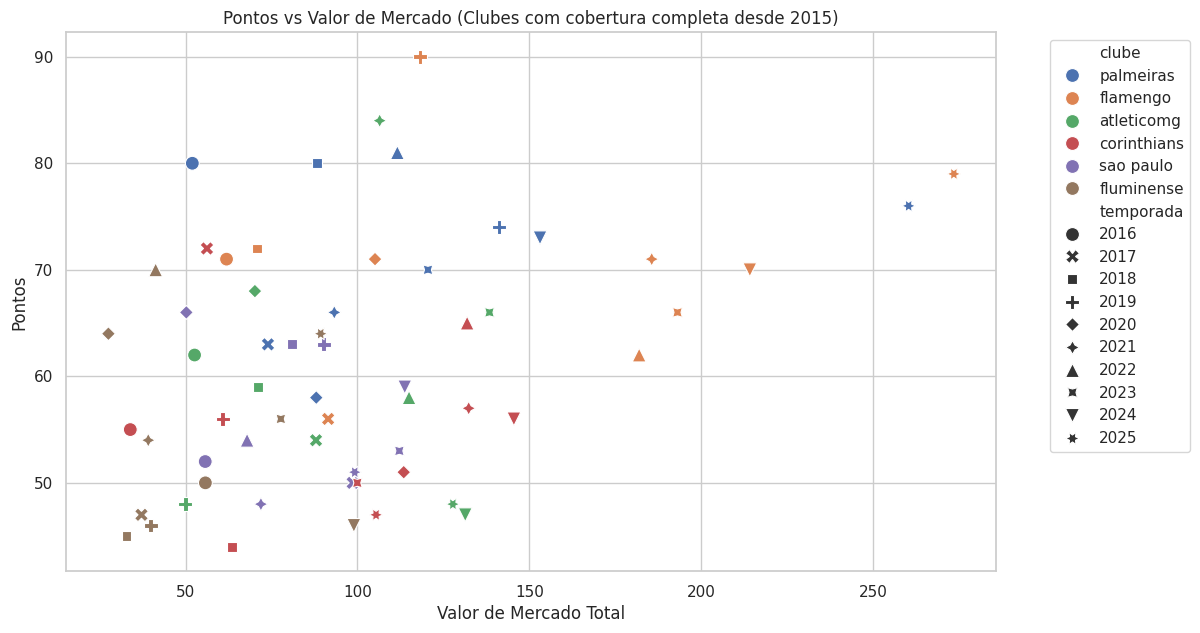

In [148]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_filtrado,
    x='valor_mercado_total',
    y='pontos',
    hue='clube',        # agora só clubes consistentes
    style='temporada',
    s=100
)

plt.title('Pontos vs Valor de Mercado (Clubes com cobertura completa desde 2015)')
plt.xlabel('Valor de Mercado Total')
plt.ylabel('Pontos')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

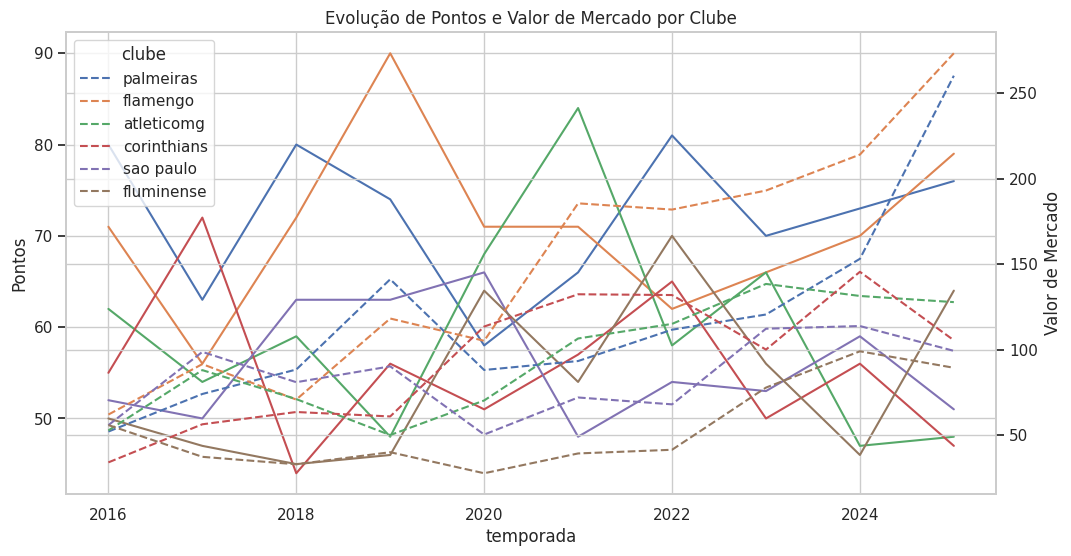

In [149]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

sns.lineplot(
    data=df_filtrado,
    x='temporada',
    y='pontos',
    hue='clube',
    ax=ax1,
    legend=False
)

sns.lineplot(
    data=df_filtrado,
    x='temporada',
    y='valor_mercado_total',
    hue='clube',
    ax=ax2,
    linestyle='dashed'
)

ax1.set_ylabel('Pontos')
ax2.set_ylabel('Valor de Mercado')

plt.title('Evolução de Pontos e Valor de Mercado por Clube')
plt.show()

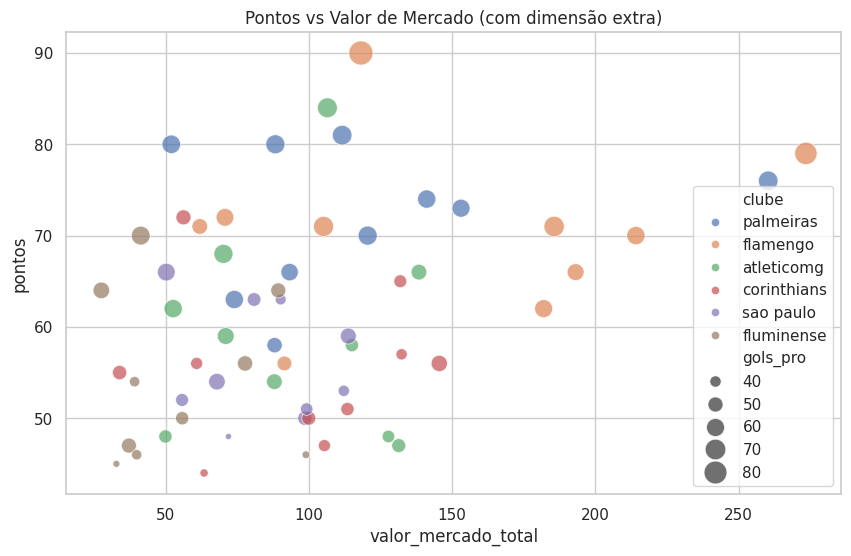

In [150]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtrado,
    x='valor_mercado_total',
    y='pontos',
    size='gols_pro',  # ou outra métrica
    hue='clube',
    alpha=0.7,
    sizes=(20, 300)
)

plt.title('Pontos vs Valor de Mercado (com dimensão extra)')
plt.show()

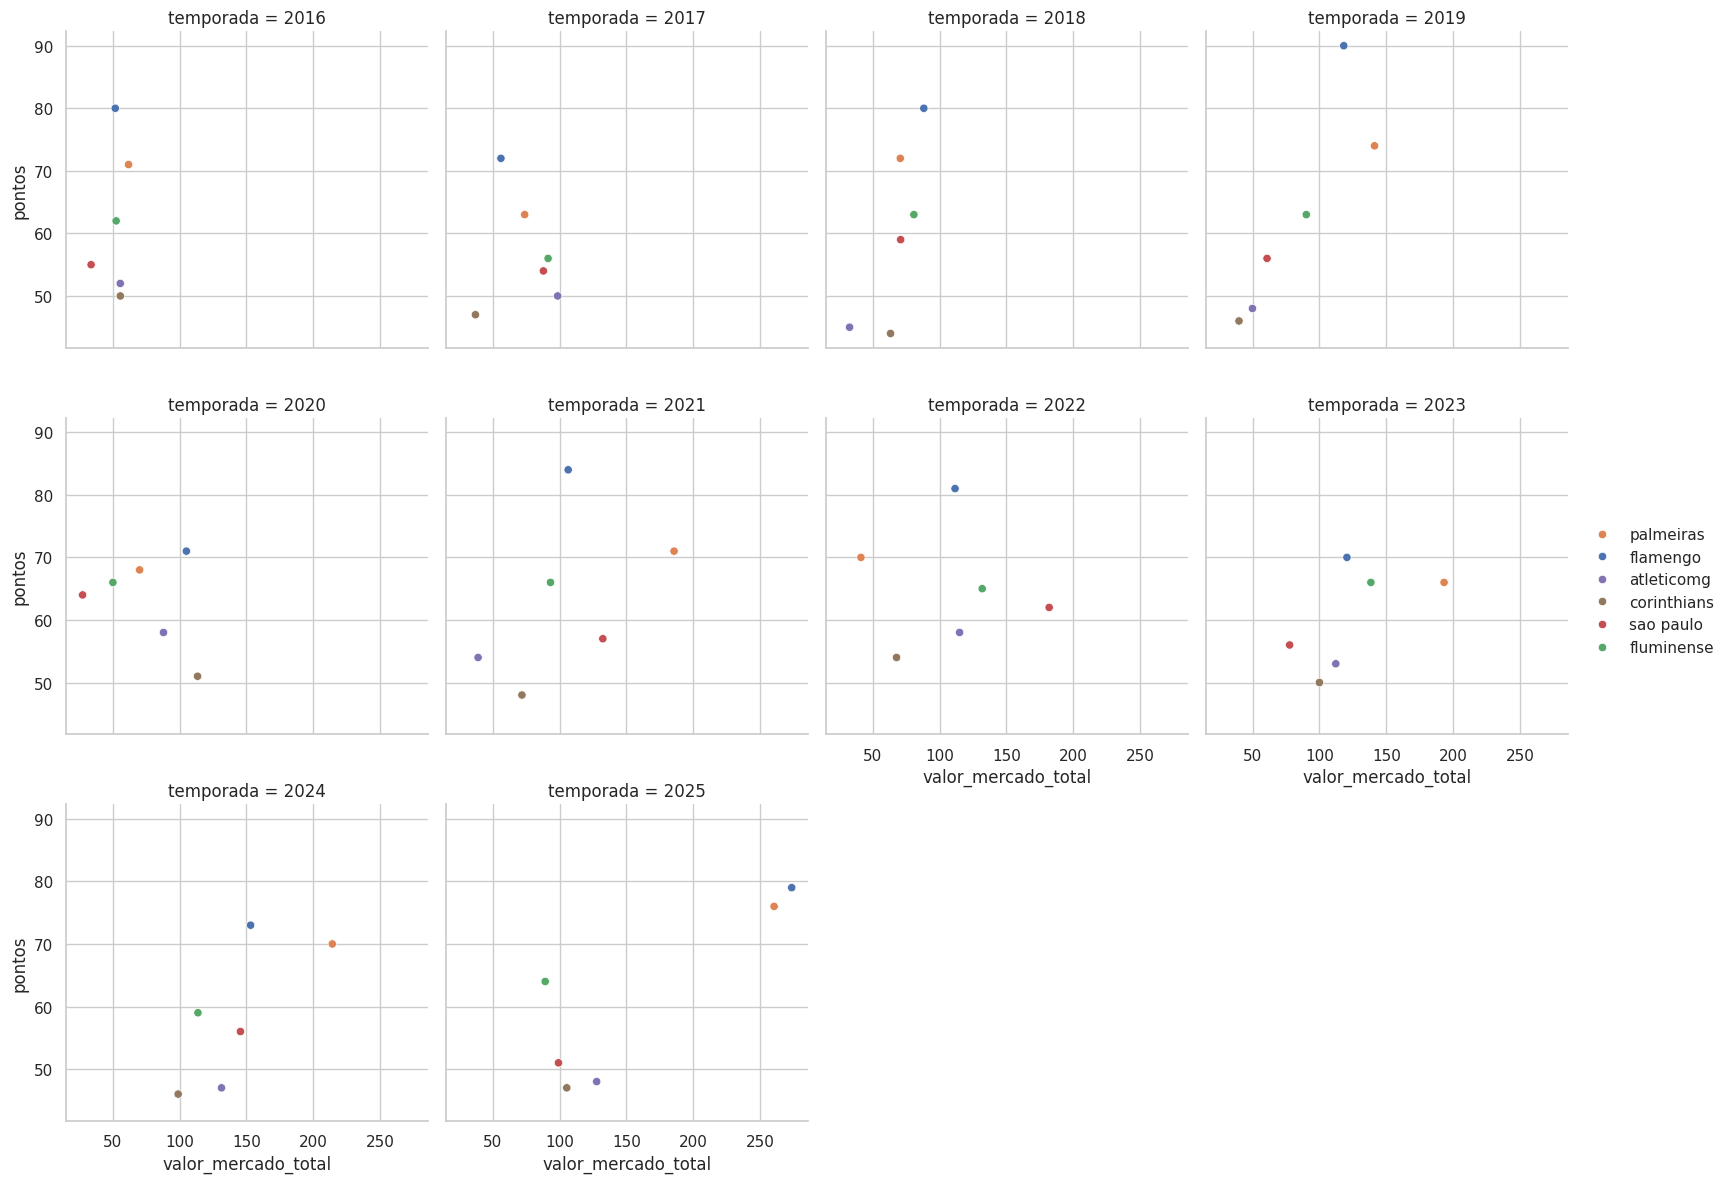

In [151]:
g = sns.FacetGrid(df_filtrado, col='temporada', col_wrap=4, height=4)

g.map_dataframe(
    sns.scatterplot,
    x='valor_mercado_total',
    y='pontos',
    hue='clube'
)

g.add_legend()

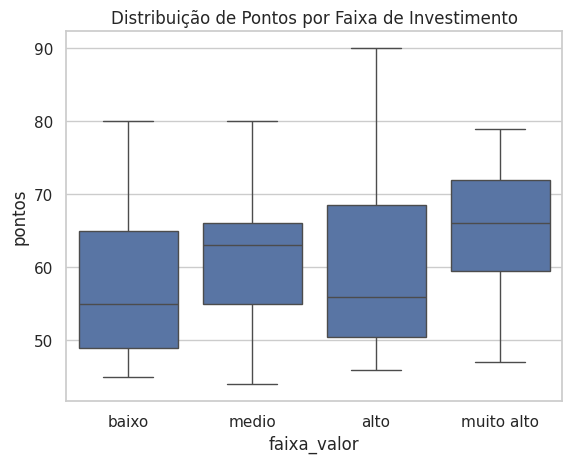

In [152]:
df_filtrado['faixa_valor'] = pd.qcut(
    df_filtrado['valor_mercado_total'],
    q=4,
    labels=['baixo', 'medio', 'alto', 'muito alto']
)

sns.boxplot(
    data=df_filtrado,
    x='faixa_valor',
    y='pontos'
)

plt.title('Distribuição de Pontos por Faixa de Investimento')
plt.show()

# ETAPA 2 — Análise univariada das variáveis-chave

2.1 Variavel-alvo: posicao_final, distribuição das posições ao longo das temporadas

faixa
meio       0.30
top5       0.25
top10      0.25
bottom4    0.20
Name: proportion, dtype: float64


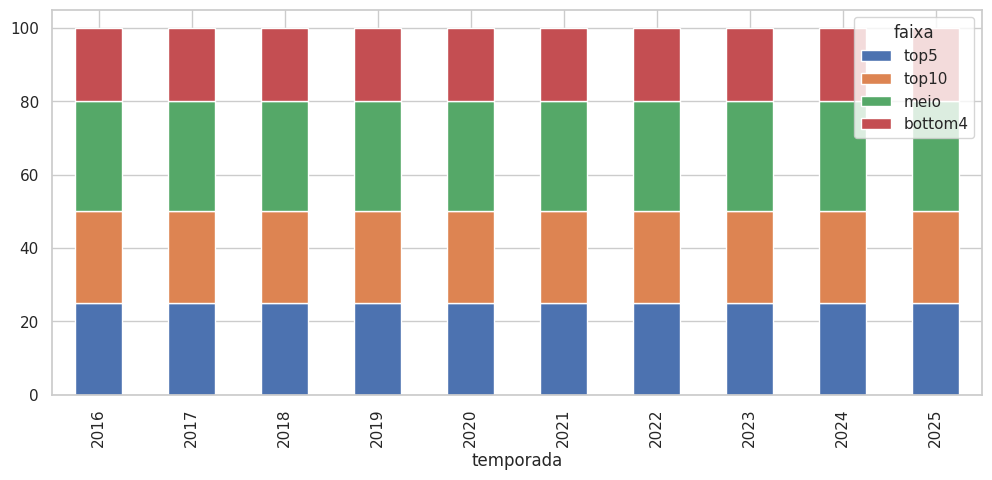

In [153]:
df['faixa'] = pd.cut(
    df['posicao_final'],
    bins=[0, 5, 10, 16, 20],
    labels=['top5', 'top10', 'meio', 'bottom4']
)

dist = df.groupby(['temporada','faixa']).size().unstack(fill_value=0)
dist_pct = dist.div(dist.sum(axis=1), axis=0) * 100

dist_pct.plot(kind='bar', stacked=True, figsize=(12,5))
print(df['faixa'].value_counts(normalize=True))

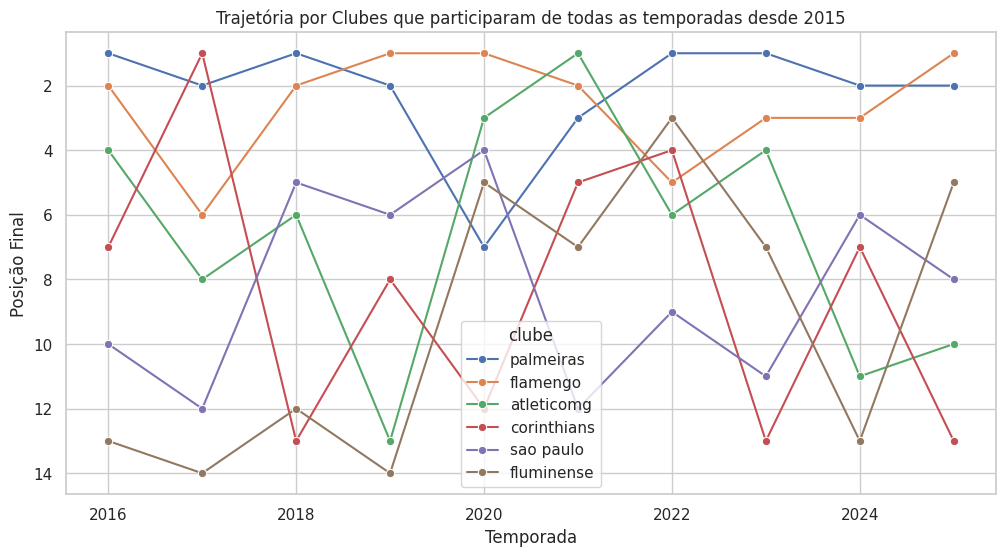

In [154]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_filtrado,
    x='temporada',
    y='posicao_final',
    hue='clube',
    marker='o'
)

plt.gca().invert_yaxis()

plt.xlabel('Temporada')
plt.ylabel('Posição Final')
plt.title('Trajetória por Clubes que participaram de todas as temporadas desde 2015')

plt.show()

Text(0.5, 1.0, 'Frequência de posição final por clube')

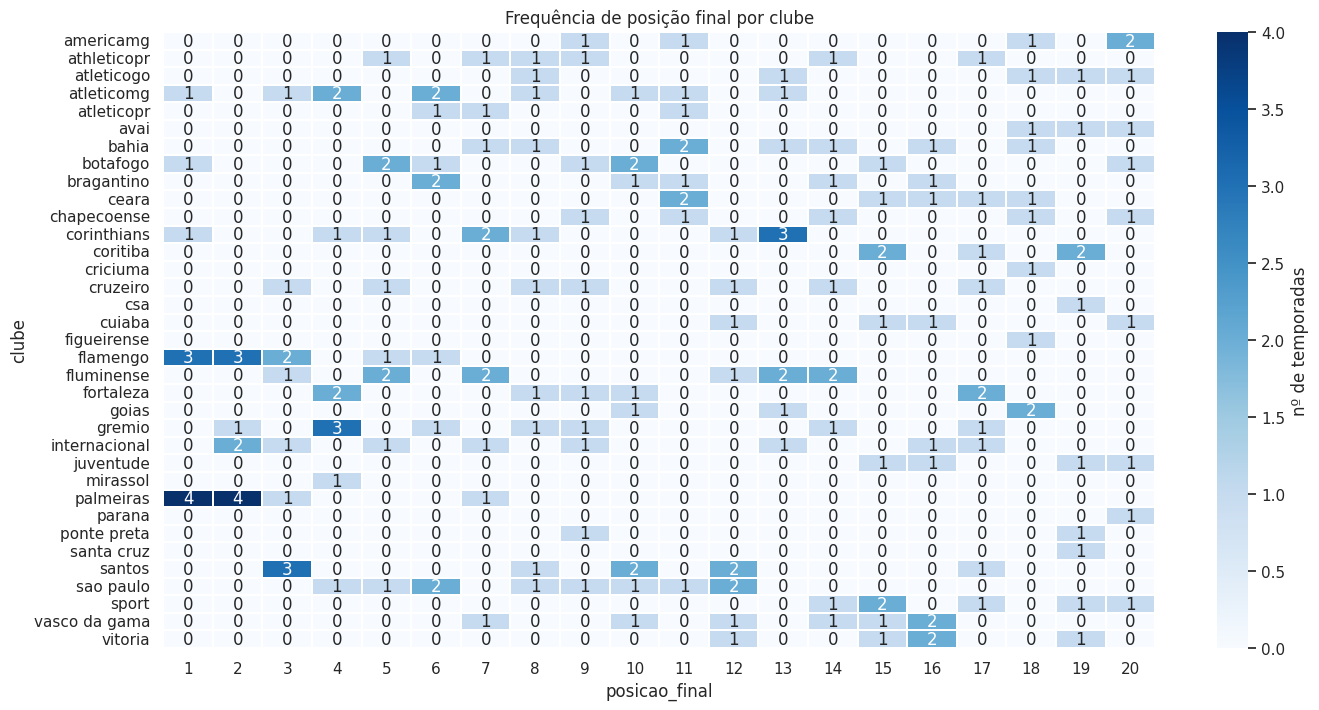

In [155]:
pivot = df.pivot_table(
    index='clube',
    columns='posicao_final',
    values='temporada',
    aggfunc='count',
    fill_value=0
)

import seaborn as sns
plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='Blues', linewidths=0.3,
            linecolor='white', annot=True, fmt='d',
            cbar_kws={'label': 'nº de temporadas'})
plt.title('Frequência de posição final por clube')

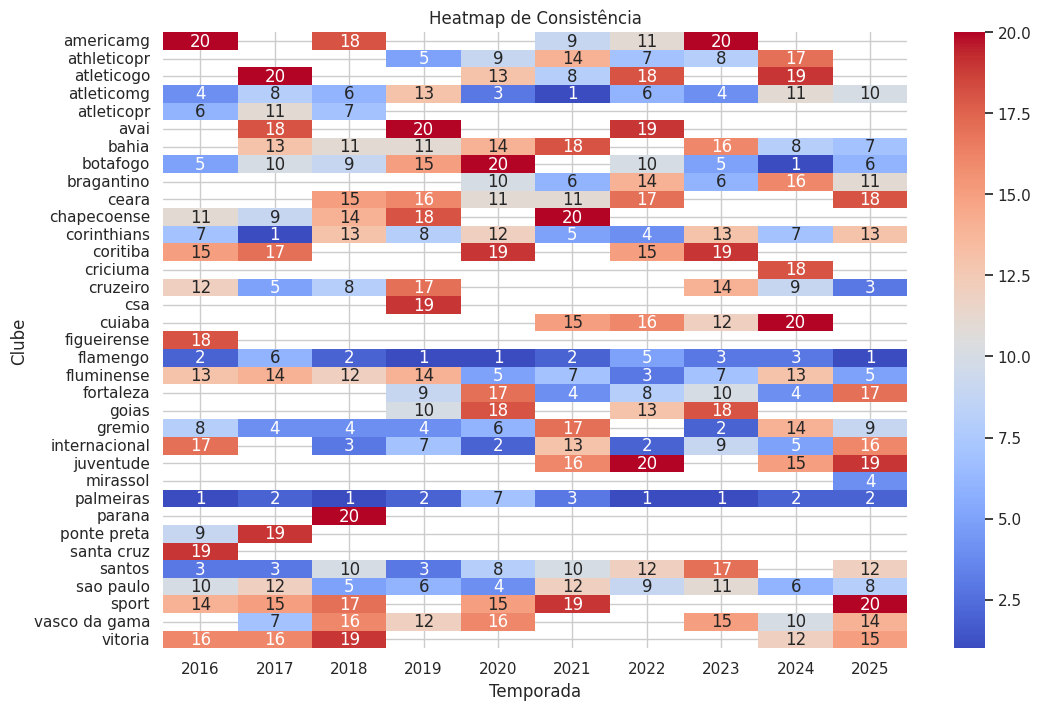

In [156]:
pivot = df.pivot_table(
    index='clube',
    columns='temporada',
    values='posicao_final'
)

plt.figure(figsize=(12,8))

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='coolwarm')

plt.xlabel('Temporada')
plt.ylabel('Clube')
plt.title('Heatmap de Consistência')

plt.show()

## 2.2 Valor de mercado e variação


In [157]:
df

,clube,numero_jogadores,media_idade,estrangeiros,media_valor_mercado_,valor_mercado_total,posicao_final,v,e,d,gols_pro,gols_contra,sg,pontos,temporada,log_valor_mercado_total,faixa
0,palmeiras,47.0,25.0,5.0,1.110,51.95,1,24,8,6,62,32,30,80,2016,3.969348,top5
1,flamengo,42.0,24.3,6.0,1.470,61.90,2,20,11,7,52,35,17,71,2016,4.141546,top5
2,santos,53.0,22.4,8.0,0.350,18.53,3,22,5,11,59,35,24,71,2016,2.971952,top5
3,atleticomg,61.0,22.9,6.0,0.862,52.60,4,17,11,9,61,50,11,62,2016,3.981549,top5
4,botafogo,52.0,23.6,5.0,0.329,17.10,5,17,8,13,43,39,4,59,2016,2.895912,top5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,internacional,52.0,23.4,12.0,1.600,83.25,16,11,11,16,44,57,-13,44,2025,4.433789,meio
196,fortaleza,57.0,26.0,15.0,1.090,61.95,17,11,10,17,43,58,-15,43,2025,4.142341,bottom4
197,ceara,48.0,25.7,5.0,0.744,35.73,18,11,10,17,34,40,-6,43,2025,3.603594,bottom4
198,juventude,57.0,25.3,5.0,0.554,31.55,19,9,8,21,35,69,-34,35,2025,3.482777,bottom4


In [158]:
df = df.sort_values(by=['clube', 'temporada'])
df['variacao_valor_percentual'] = df.groupby('clube')['valor_mercado_total'].pct_change() * 100
df['variacao_valor_percentual'] = df['variacao_valor_percentual'].fillna(0)
display(df[['clube', 'temporada', 'valor_mercado_total', 'variacao_valor_percentual']].head(30))

,clube,temporada,valor_mercado_total,variacao_valor_percentual
19,americamg,2016,35.25,0.000000
57,americamg,2018,30.75,-12.765957
108,americamg,2021,16.95,-44.878049
130,americamg,2022,24.58,45.014749
159,americamg,2023,34.18,39.056143
64,athleticopr,2019,36.95,0.000000
88,athleticopr,2020,30.85,-16.508796
113,athleticopr,2021,31.35,1.620746
126,athleticopr,2022,70.93,126.251994
147,athleticopr,2023,57.73,-18.609897


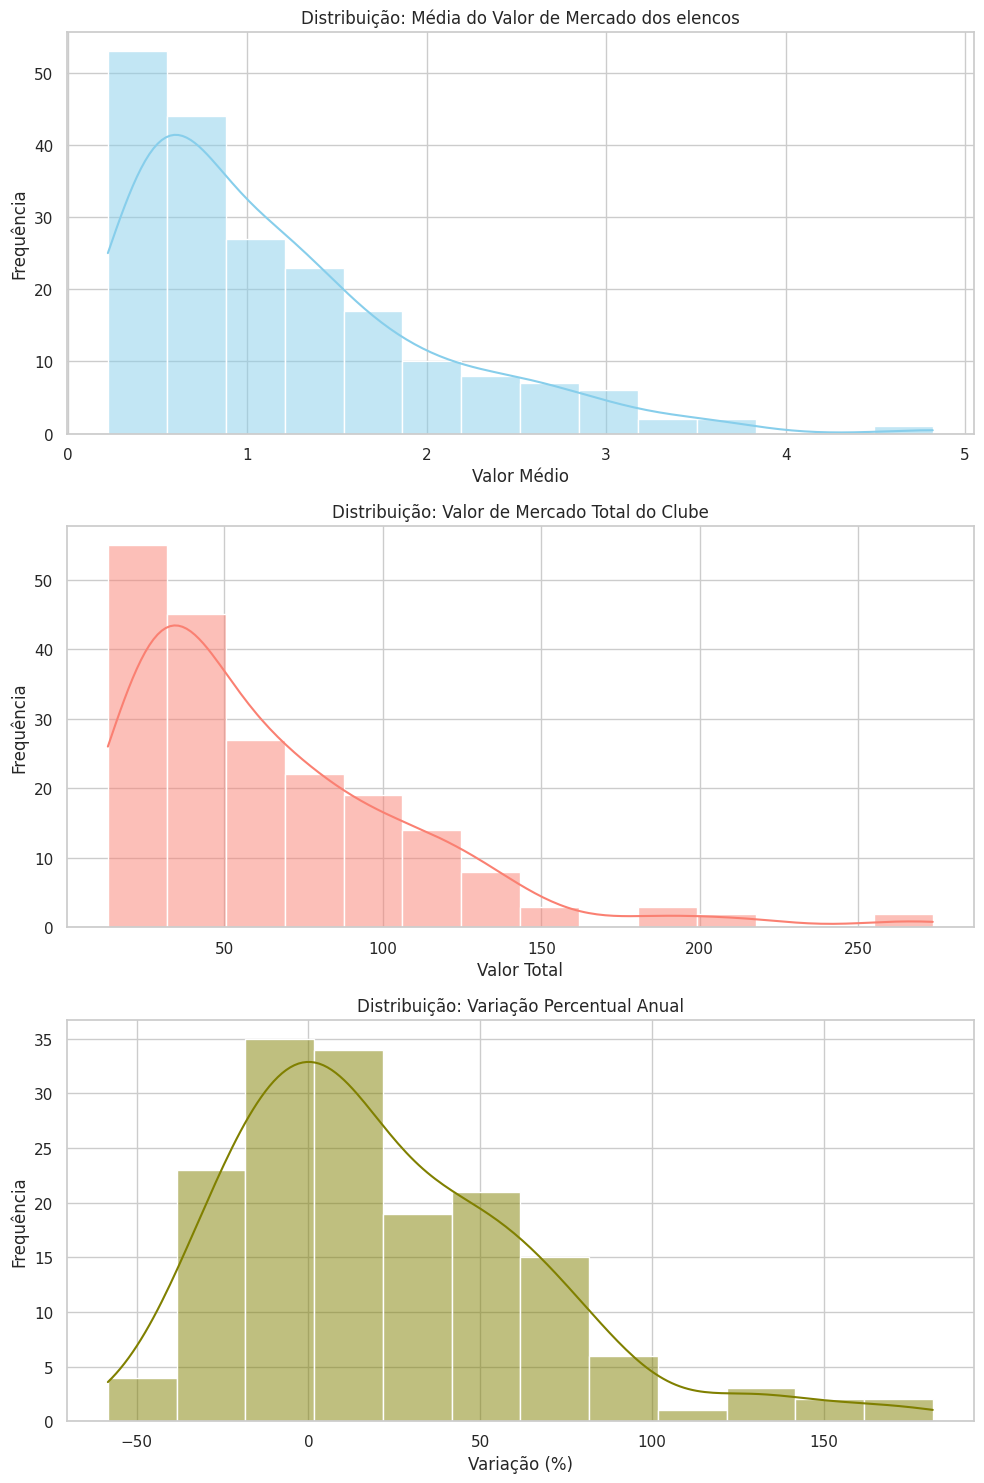

In [159]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

sns.histplot(df['media_valor_mercado_'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição: Média do Valor de Mercado dos elencos')
axes[0].set_xlabel('Valor Médio')
axes[0].set_ylabel('Frequência')

sns.histplot(df['valor_mercado_total'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição: Valor de Mercado Total do Clube')
axes[1].set_xlabel('Valor Total')
axes[1].set_ylabel('Frequência')

variacao_real = df[df['variacao_valor_percentual'] != 0]['variacao_valor_percentual']
sns.histplot(variacao_real, kde=True, ax=axes[2], color='olive')
axes[2].set_title('Distribuição: Variação Percentual Anual')
axes[2].set_xlabel('Variação (%)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 2.3 Composição do elenco


In [160]:
bins = [0, 23, 28, 33, 100]
labels = ['Jovem (Sub-23)', 'Equilibrado(23 - 28)', 'Experiente(28 - 33)', 'Veterano(33 +)']

df['perfil_etario'] = pd.cut(df['media_idade'], bins=bins, labels=labels)

/tmp/ipykernel_2963/1920206035.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='perfil_etario', ax=axes[1, 1], palette='viridis')


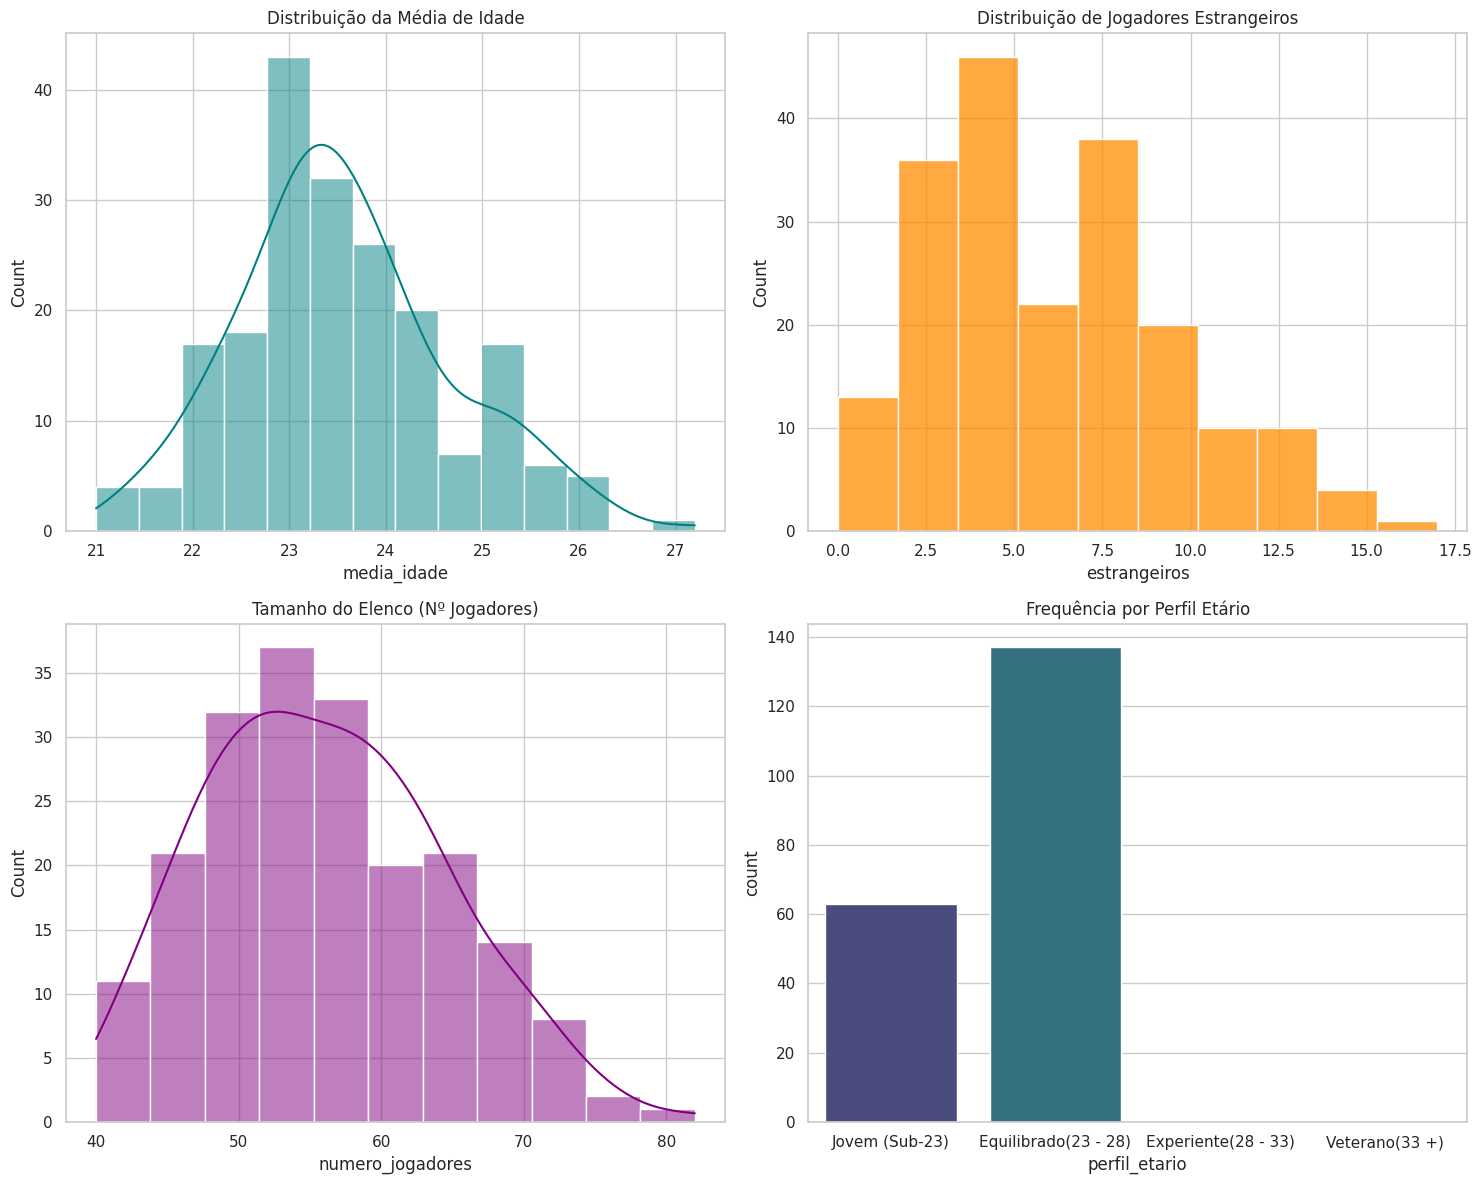

In [161]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(df['media_idade'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribuição da Média de Idade')

sns.histplot(df['estrangeiros'], kde=False, ax=axes[0, 1], color='darkorange', bins=10)
axes[0, 1].set_title('Distribuição de Jogadores Estrangeiros')

sns.histplot(df['numero_jogadores'], kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Tamanho do Elenco (Nº Jogadores)')

sns.countplot(data=df, x='perfil_etario', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Frequência por Perfil Etário')

plt.tight_layout()
plt.show()

## 2.4 Desempenho em campo

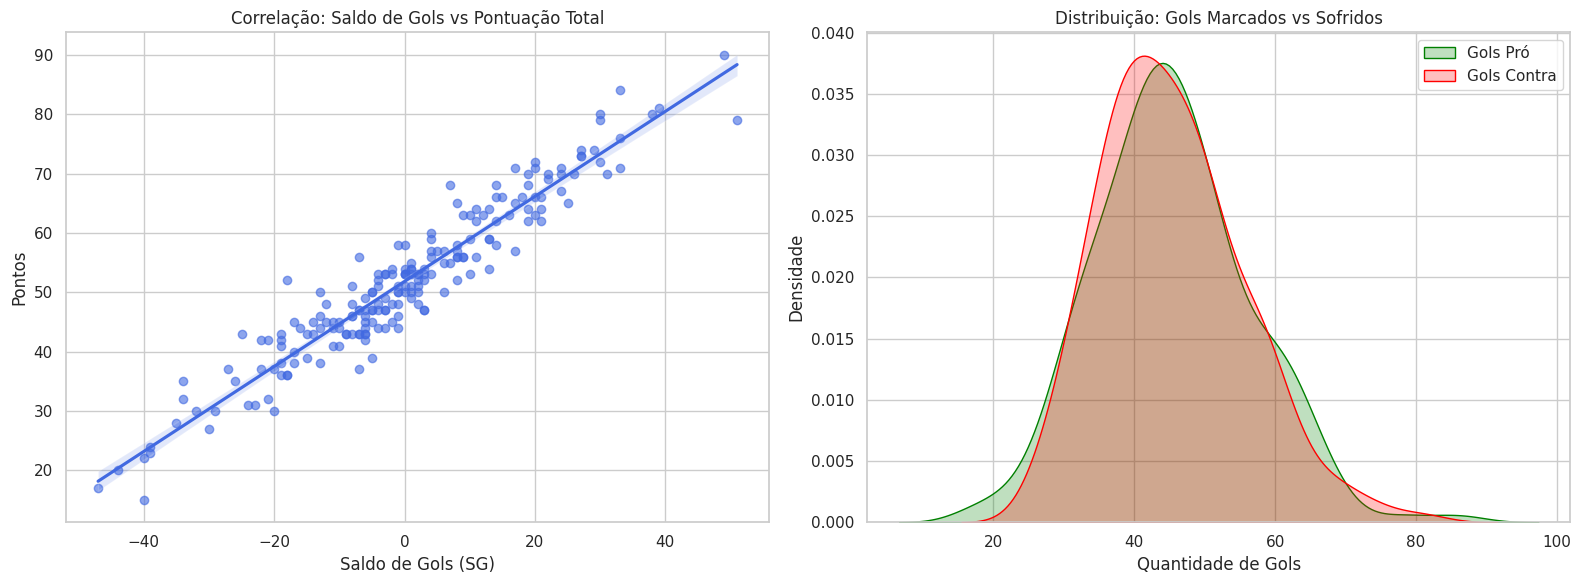

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='sg', y='pontos', ax=axes[0], color='royalblue', scatter_kws={'alpha':0.6})
axes[0].set_title('Correlação: Saldo de Gols vs Pontuação Total')
axes[0].set_xlabel('Saldo de Gols (SG)')
axes[0].set_ylabel('Pontos')

sns.kdeplot(df['gols_pro'], fill=True, label='Gols Pró', ax=axes[1], color='green')
sns.kdeplot(df['gols_contra'], fill=True, label='Gols Contra', ax=axes[1], color='red')
axes[1].set_title('Distribuição: Gols Marcados vs Sofridos')
axes[1].set_xlabel('Quantidade de Gols')
axes[1].set_ylabel('Densidade')
axes[1].legend()

plt.tight_layout()
plt.show()

# ETAPA 3 — Análise bivariada vs posição_final

In [163]:
# Métrica: Quanto o clube investiu para cada ponto ganho
df['custo_por_ponto'] = df['valor_mercado_total'] / df['pontos']




In [164]:
media_custo = df['custo_por_ponto'].mean()
print(f"Custo médio por ponto na liga: {media_custo:.2f}")

Custo médio por ponto na liga: 1.21


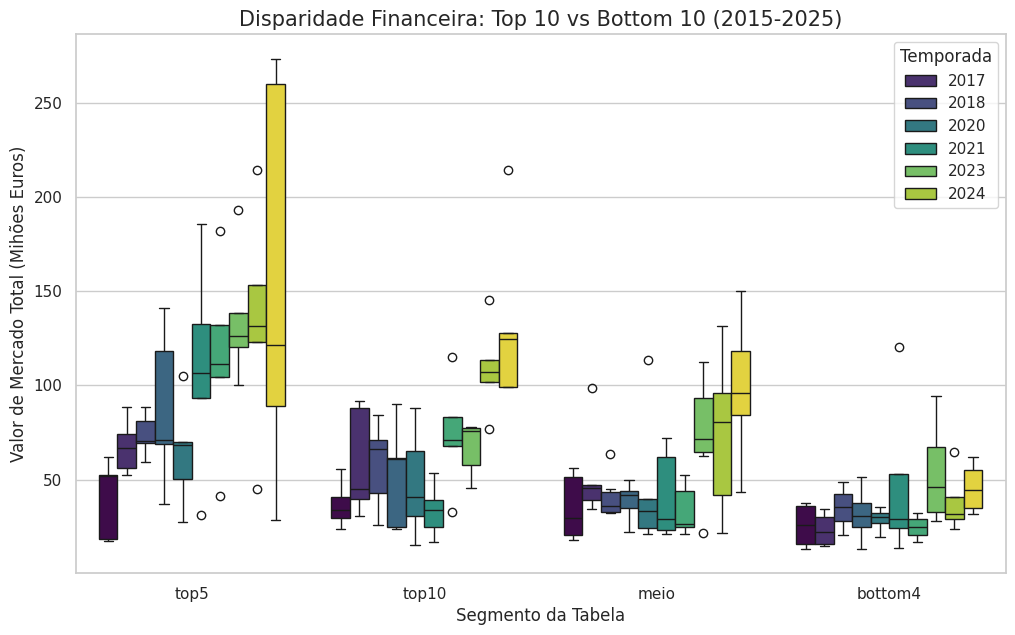

In [165]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.boxplot(data=df, x='faixa', y='valor_mercado_total', hue='temporada', palette='viridis')

# Adicionando títulos e rótulos
plt.title('Disparidade Financeira: Top 10 vs Bottom 10 (2015-2025)', fontsize=15)
plt.xlabel('Segmento da Tabela', fontsize=12)
plt.ylabel('Valor de Mercado Total (Mihões Euros)', fontsize=12)
plt.legend(title='Temporada')

plt.show()

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


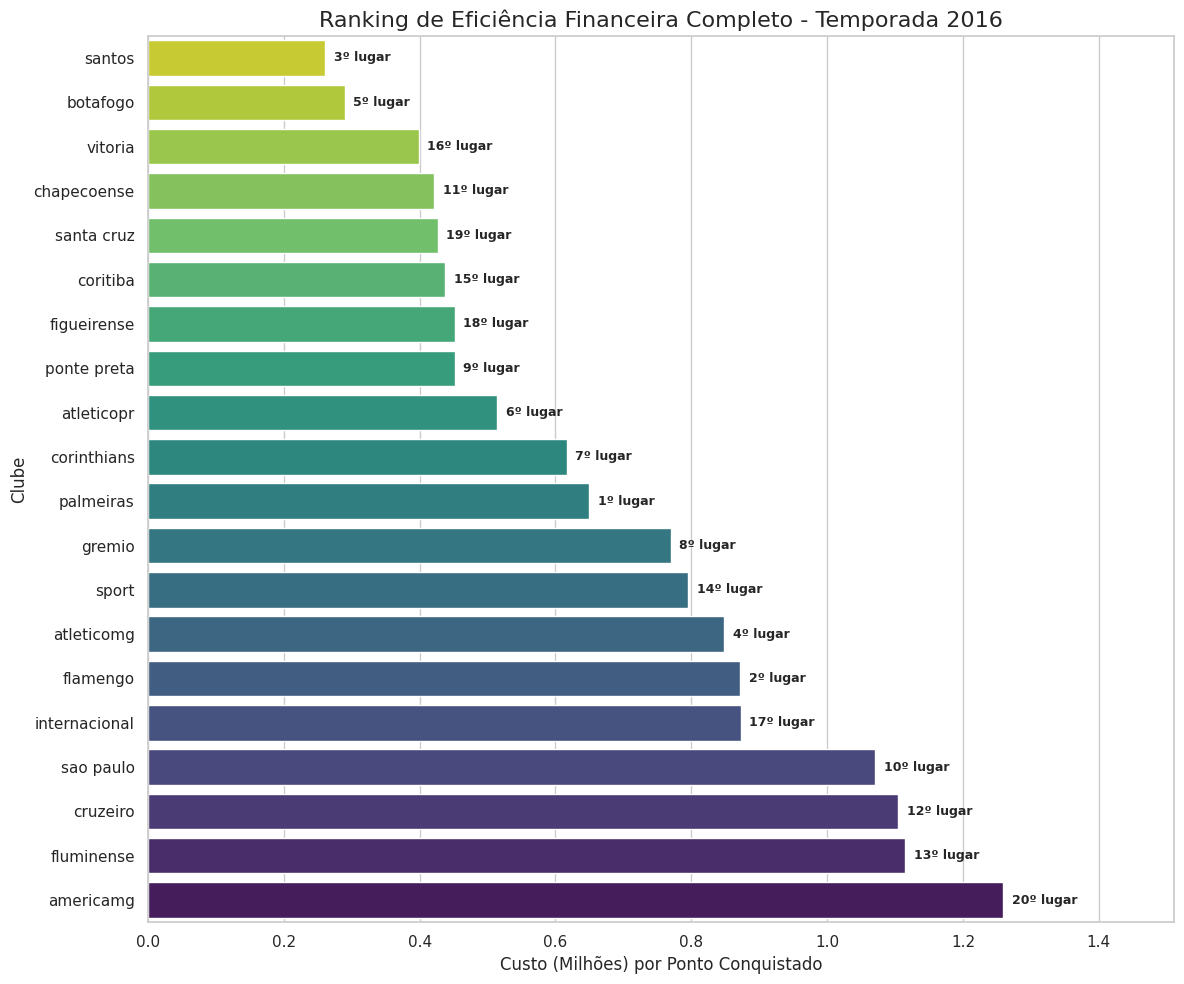

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


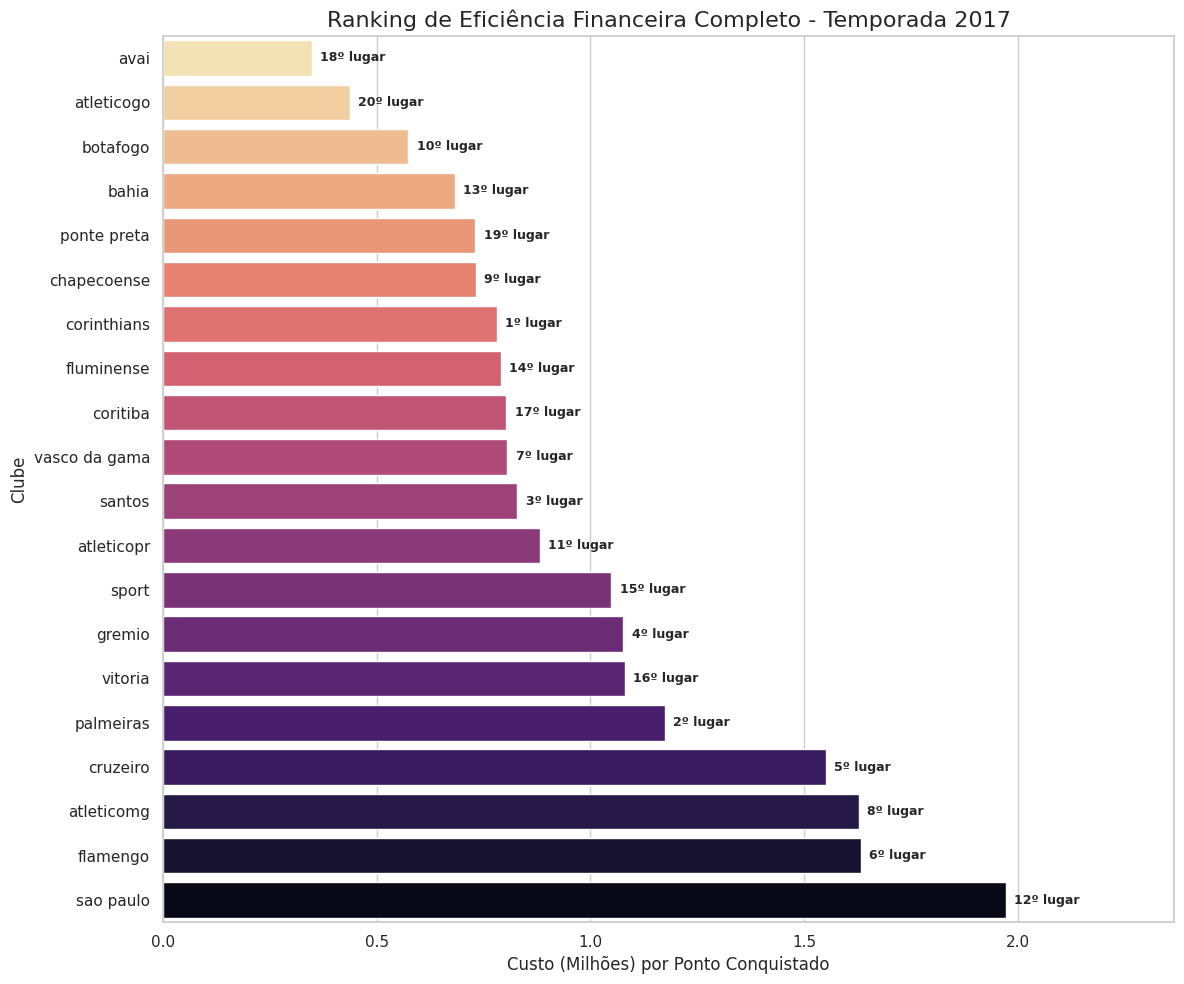

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


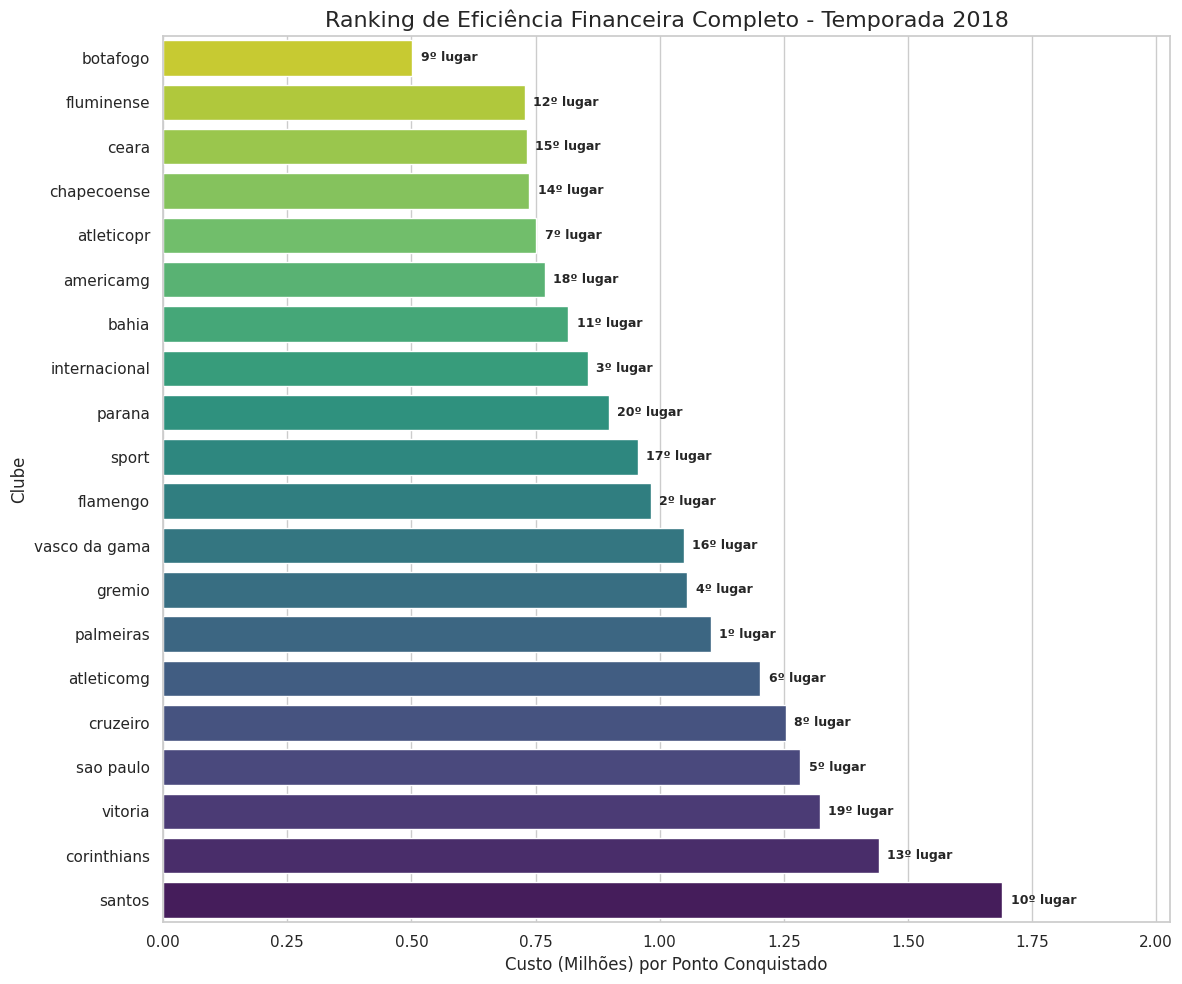

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


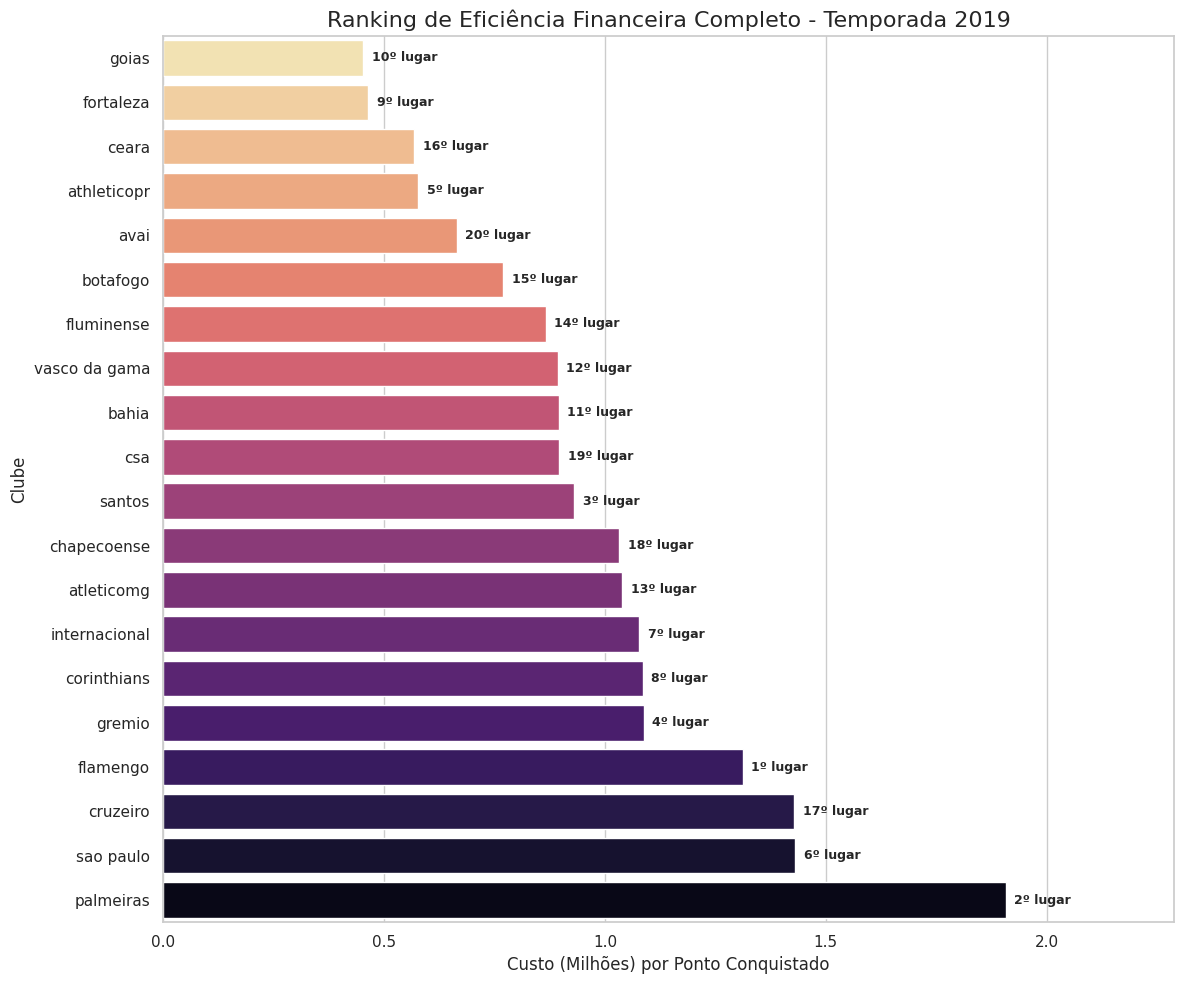

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


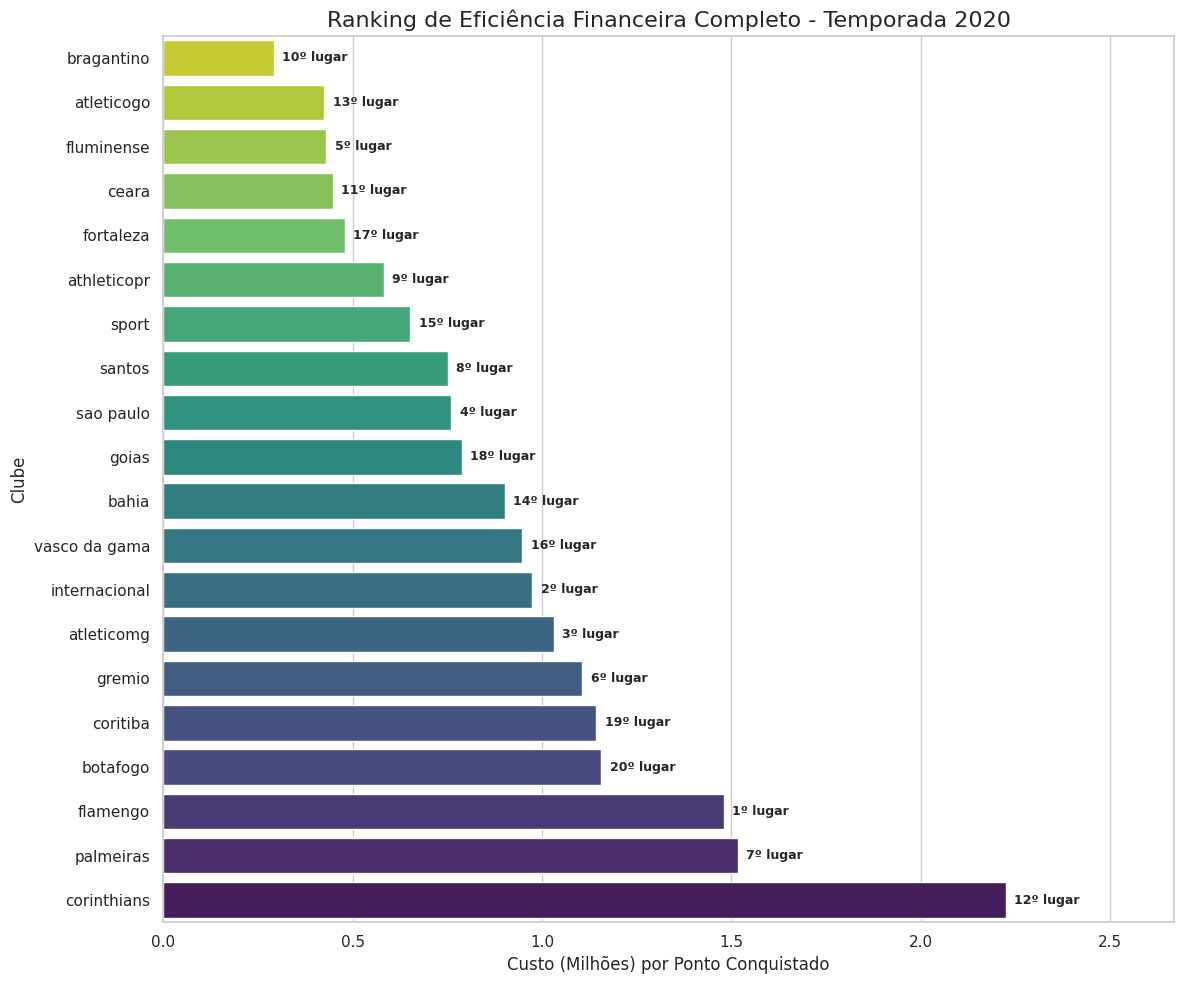

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


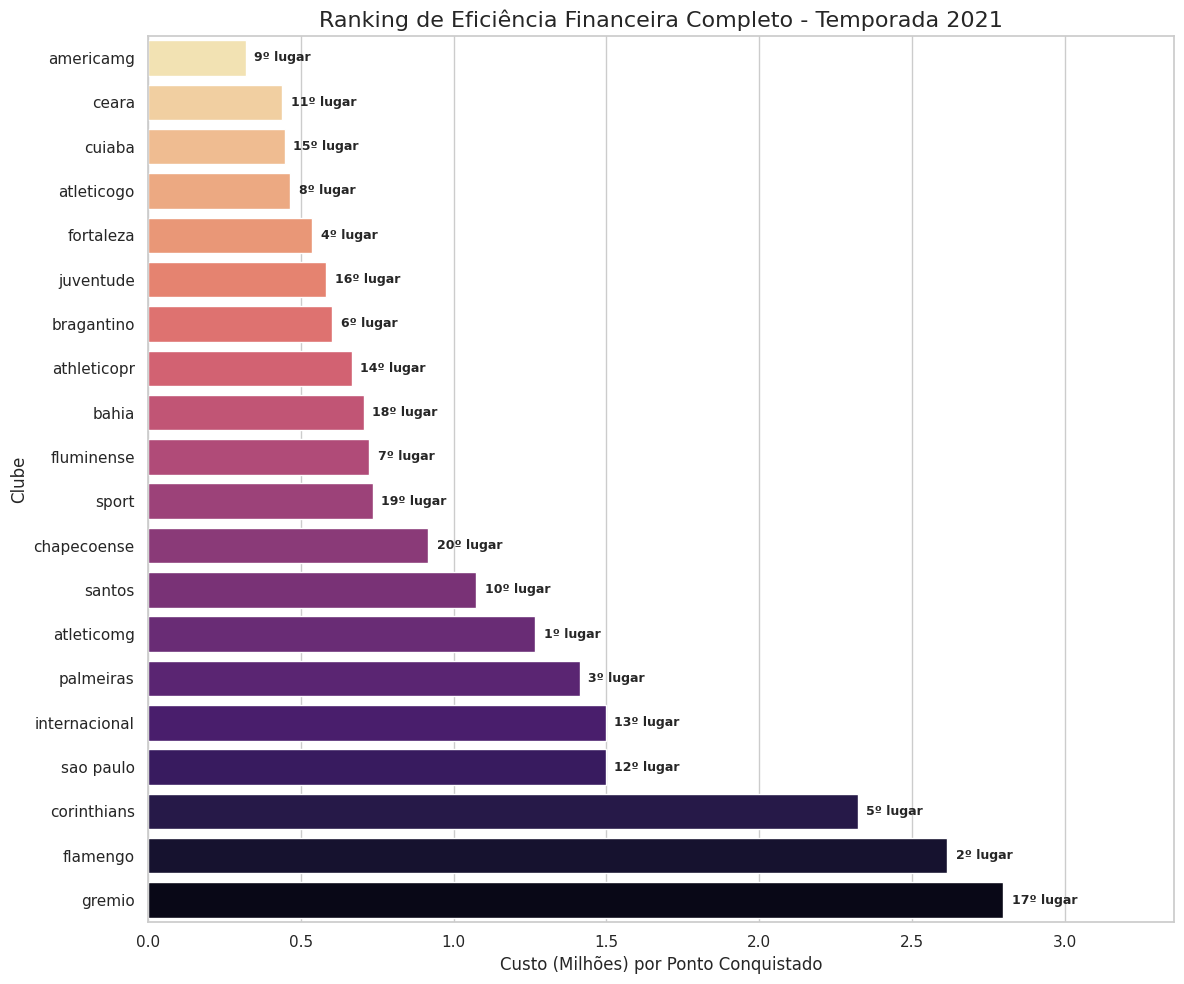

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


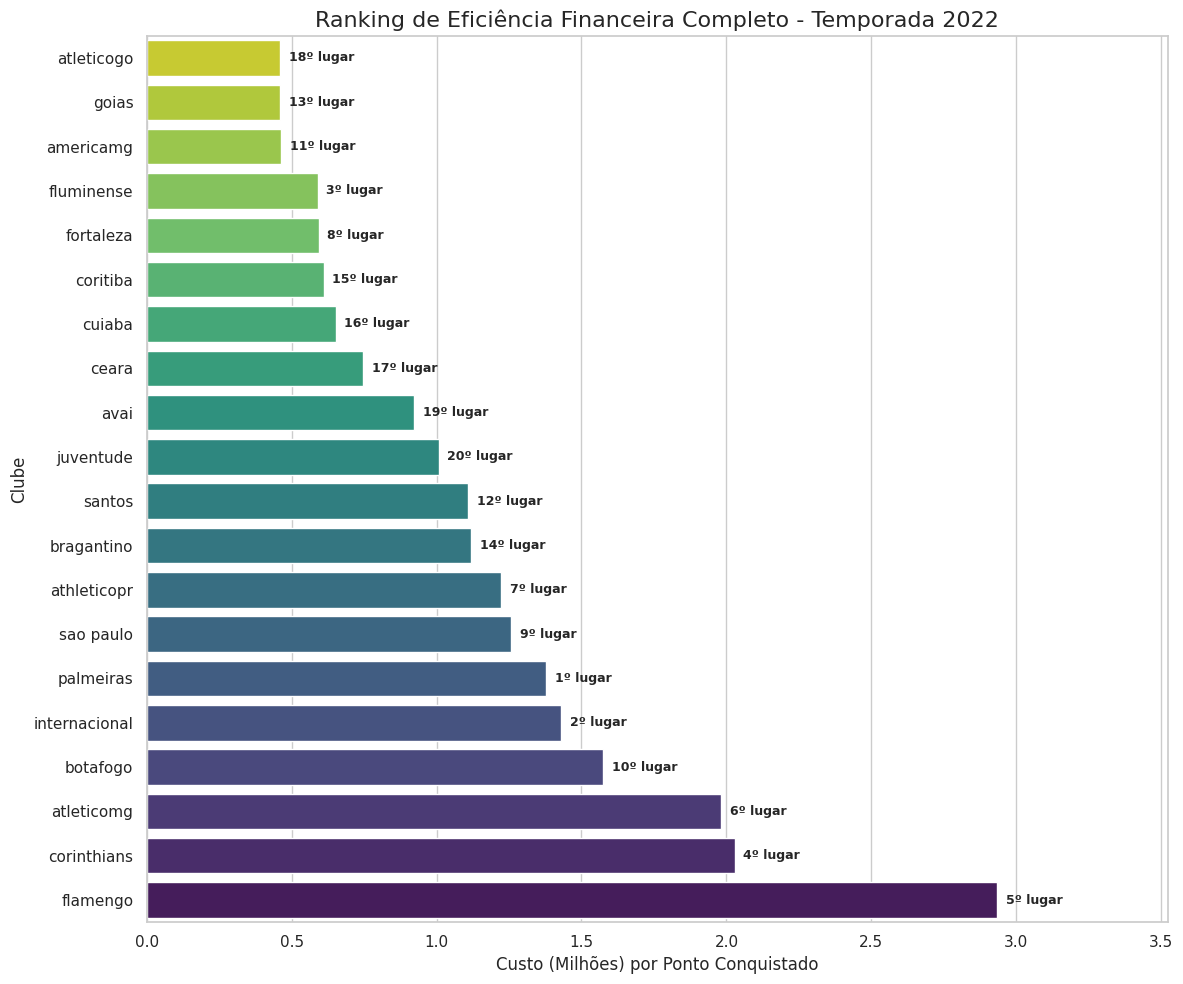

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


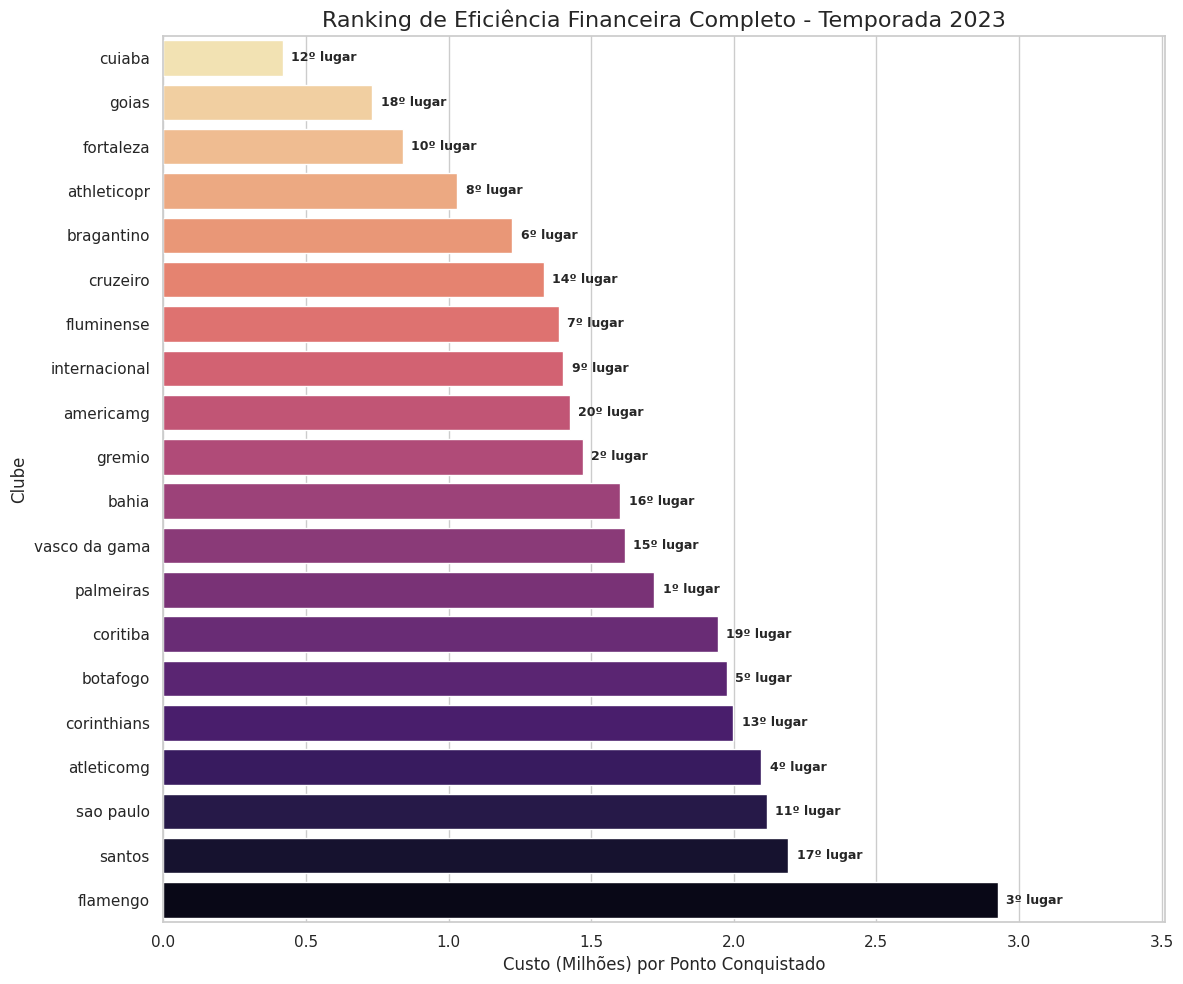

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


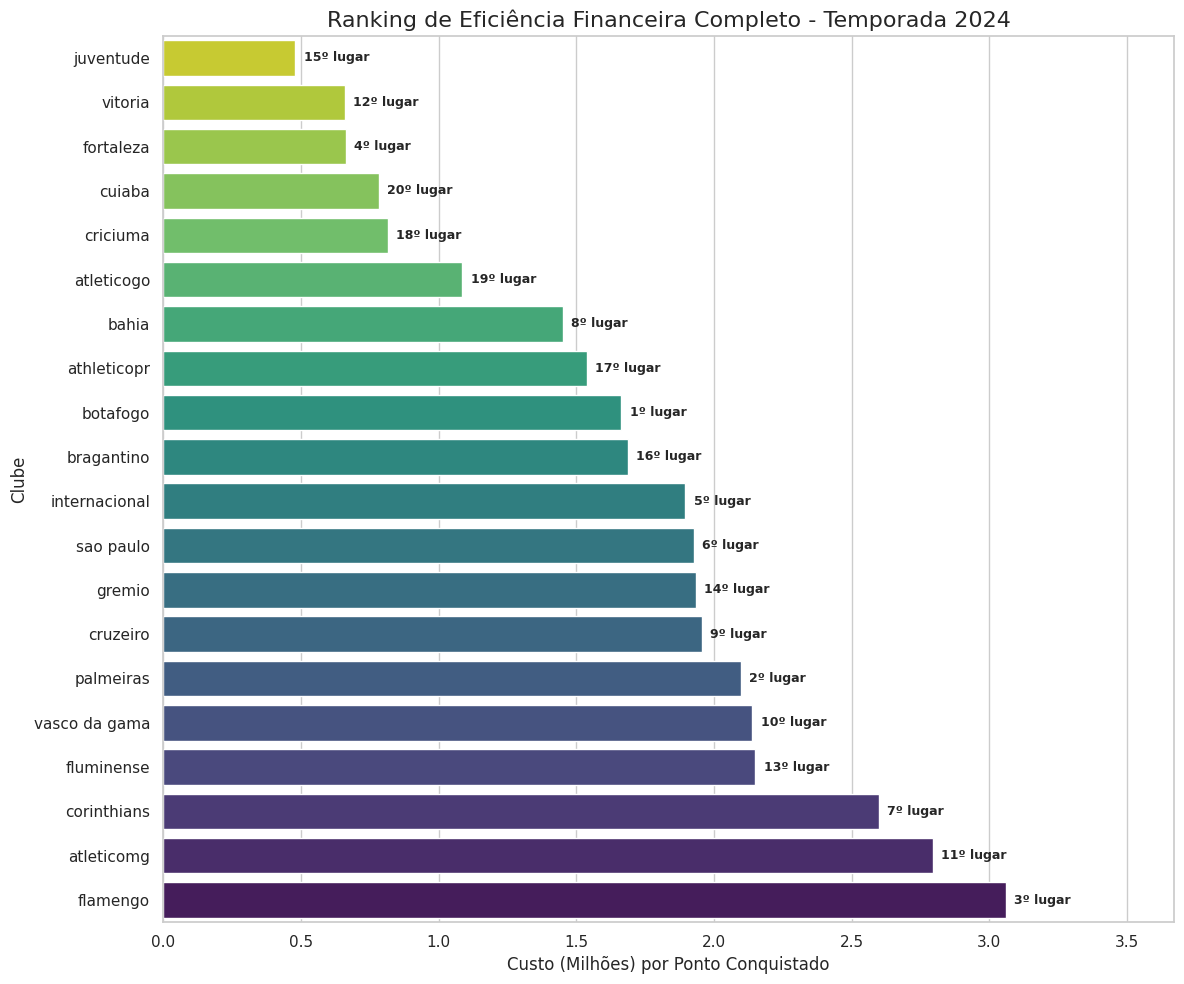

/tmp/ipykernel_2963/1613098144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)


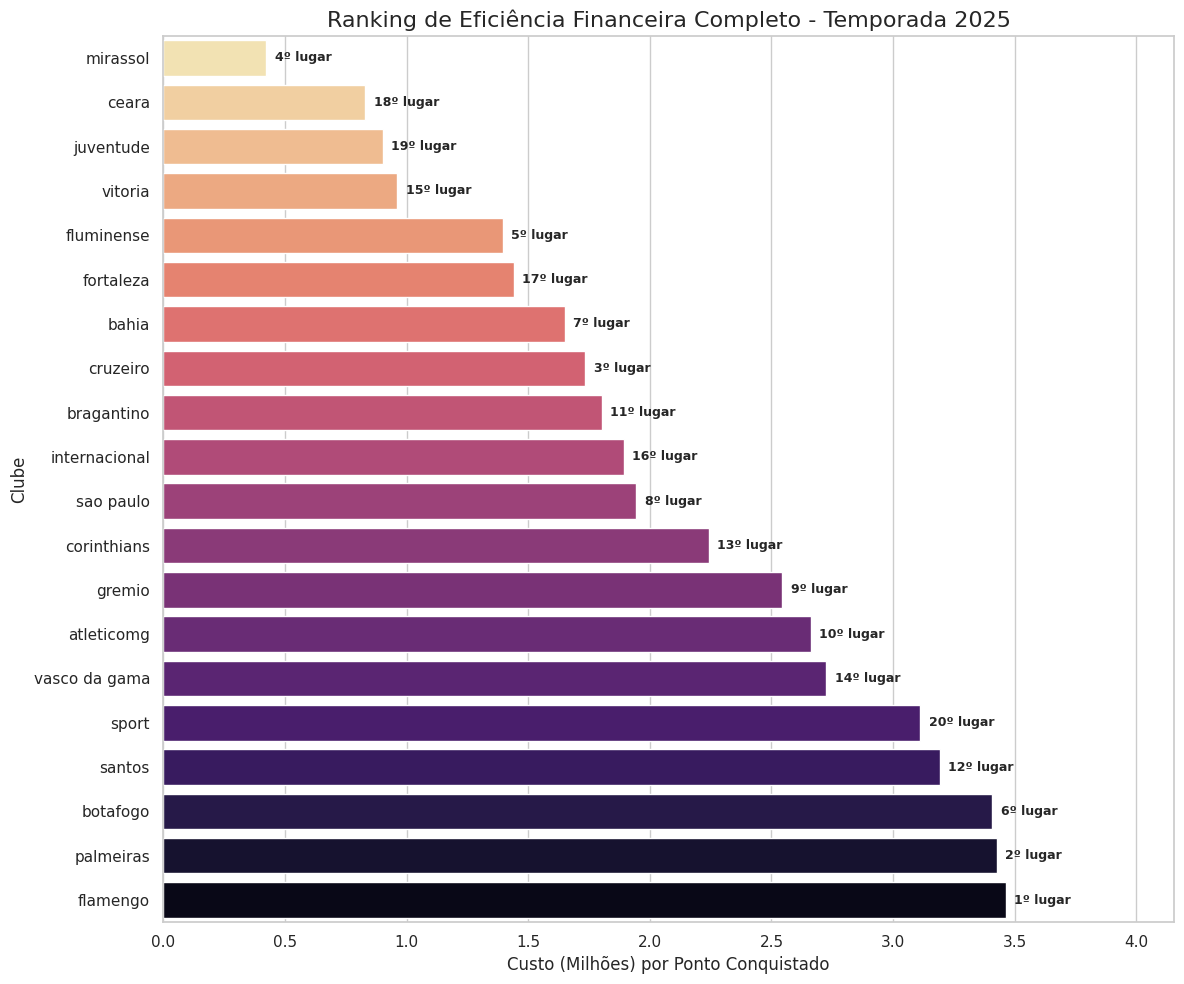

In [166]:
# 1. Garantir que a métrica de eficiência existe
df['custo_por_ponto'] = df['valor_mercado_total'] / df['pontos']

# 2. Lista de anos únicos
anos = sorted(df['temporada'].unique())

for ano in anos:
    # Filtrar dados do ano
    df_ano = df[df['temporada'] == ano].copy()
    
    # Ordenar por eficiência (todos os clubes)
    df_plot = df_ano.sort_values('custo_por_ponto')
    
    # Aumentamos a altura da figura (figsize=(10, 10)) para caber os 20 clubes confortavelmente
    plt.figure(figsize=(12, 10))
    
    # Definir paleta de cores degradê para destacar os extremos
    cor = 'viridis_r' if ano % 2 == 0 else 'magma_r'
    ax = sns.barplot(data=df_plot, x='custo_por_ponto', y='clube', palette=cor)
    
    # 3. Adicionar rótulos de posição
    for i, bar in enumerate(ax.patches):
        posicao = int(df_plot.iloc[i]['posicao_final'])
        custo = df_plot.iloc[i]['custo_por_ponto']
        
        # Posicionar o texto ligeiramente à frente da barra
        ax.text(custo + (df_plot['custo_por_ponto'].max() * 0.01), i, 
                f'{posicao}º lugar', va='center', fontweight='bold', fontsize=9)
    
    # Customização
    plt.title(f'Ranking de Eficiência Financeira Completo - Temporada {int(ano)}', fontsize=16)
    plt.xlabel('Custo (Milhões) por Ponto Conquistado', fontsize=12)
    plt.ylabel('Clube', fontsize=12)
    
    # Ajustar o limite do eixo X para dar espaço aos rótulos de texto
    plt.xlim(0, df_plot['custo_por_ponto'].max() * 1.2)
    
    plt.tight_layout()
    plt.show()

# ETAPA 4 — Análise temporal e tendências

## 4.1 Evolução dos valores dos times por temporada

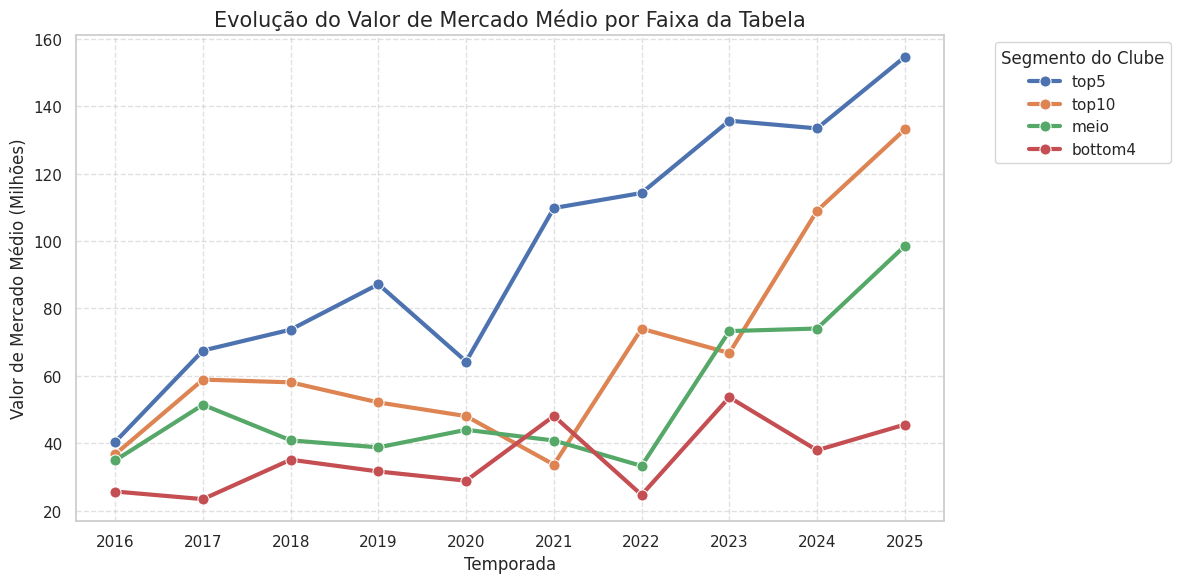

In [168]:
df_evolucao = df.groupby(['temporada', 'faixa'])['valor_mercado_total'].mean().reset_index()
plt.figure(figsize=(12, 6))
ordem_segmentos = ['top5', 'top10', 'meio', 'bottom4'] 

sns.lineplot(
    data=df_evolucao, 
    x='temporada', 
    y='valor_mercado_total', 
    hue='faixa', 
    hue_order=[s for s in ordem_segmentos if s in df_evolucao['faixa'].unique()],
    marker='o', 
    linewidth=3,
    markersize=8
)

plt.title('Evolução do Valor de Mercado Médio por Faixa da Tabela', fontsize=15)
plt.xlabel('Temporada', fontsize=12)
plt.ylabel('Valor de Mercado Médio (Milhões)', fontsize=12)

plt.xticks(df['temporada'].unique().astype(int))

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Segmento do Clube', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [169]:
df = df.sort_values(by=['clube', 'temporada'])

df['pontos_proximo_ano'] = df.groupby('clube')['pontos'].shift(-1)
df['posicao_proximo_ano'] = df.groupby('clube')['posicao_final'].shift(-1)

df_lag = df.dropna(subset=['pontos_proximo_ano'])

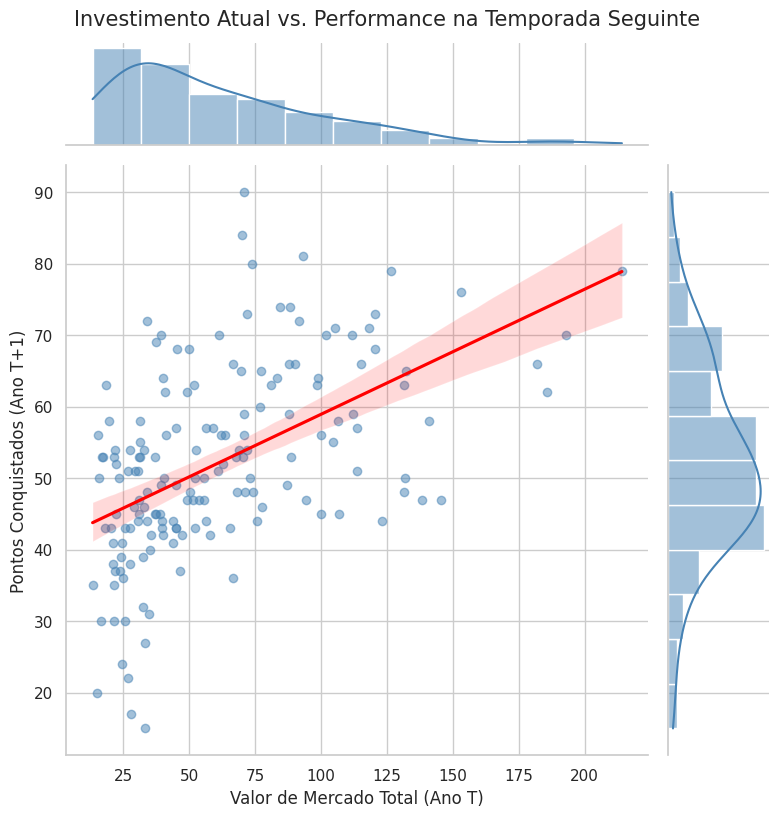

In [170]:
g = sns.jointplot(
    data=df_lag, 
    x='valor_mercado_total', 
    y='pontos_proximo_ano',
    kind='reg', # Linha de regressão
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
    height=8,
    color='steelblue'
)

# Ajustando títulos e eixos
g.fig.suptitle('Investimento Atual vs. Performance na Temporada Seguinte', y=1.02, fontsize=15)
g.set_axis_labels('Valor de Mercado Total (Ano T)', 'Pontos Conquistados (Ano T+1)', fontsize=12)

plt.show()

In [171]:
corr_imediata = df_lag['valor_mercado_total'].corr(df_lag['pontos'])
corr_antecipada = df_lag['valor_mercado_total'].corr(df_lag['pontos_proximo_ano'])

print(f"Força do investimento no mesmo ano: {corr_imediata:.4f}")
print(f"Força do investimento para o ano seguinte: {corr_antecipada:.4f}")

Força do investimento no mesmo ano: 0.5235
Força do investimento para o ano seguinte: 0.5212


In [172]:
df.to_csv('/workspaces/moneyball-brasileirao/data/dados_modelagem.csv', index= False)